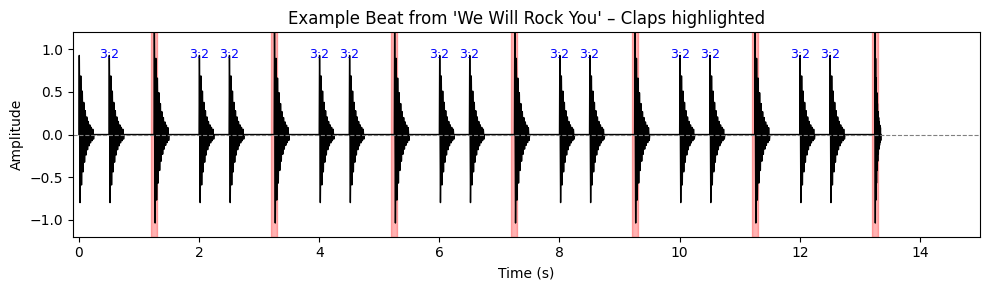

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1) CSV laden ===
df = pd.read_csv("/Users/emilschmiedl/Desktop/Proximity-Funktion/Abbildungen für Poster und Paper/matrizen fürs paper/accelerando copy.csv")

# Nur gültige Onsets (NaN ignorieren)
onsets = df["onset"].dropna().values

# === 2) Parameter ===
first_onset = onsets[0] - 0.1
duration = max(onsets) + 0.1
fs = 5000  # Samplingrate für glatte Kurve
t = np.linspace(0, duration, int(fs * duration))

wave = np.zeros_like(t)
pulse_len = int(0.25 * fs)   # Dauer jedes "Tons" (20 ms)
freq = 20                    # Frequenz des Pulses innerhalb der "Violine"
amp = 1.0                    # Amplitude

# === 3) Wellenform aufbauen ===
wave = np.zeros_like(t)

for onset, label in zip(df["onset"], df["label"]):
    start_idx = np.argmin(np.abs(t - onset))
    end_idx = min(start_idx + pulse_len, len(t))
    x = np.linspace(0, np.pi, end_idx - start_idx)
    pulse = np.sin(x * freq) * np.exp(-3 * (x / np.pi))
    
    # Claps lauter oder anders färben
    if label.lower() == "clap":
        wave[start_idx:end_idx] += pulse * amp * 1.3   # etwas stärker
    else:
        wave[start_idx:end_idx] += pulse * amp

# === 4) Plot ===
plt.figure(figsize=(10, 3))
plt.plot(t, wave, color="black", linewidth=1)

# === 5) IOI-Ratios markieren ===
iois = df["IOI"].dropna().values
ratios = np.round(np.maximum(iois[1:], iois[:-1]) / np.minimum(iois[1:], iois[:-1]), 2)

for i, r in enumerate(ratios):
    if abs(r - 1.5) < 0.1:  # etwa 3:2-Verhältnis
        x_pos = df["onset"].iloc[i+1]
        plt.text(x_pos, 0.9, "3:2", color="blue", fontsize=9, ha="center")

# Claps farblich markieren
clap_onsets = df.loc[df["label"].str.lower() == "clap", "onset"]
for c in clap_onsets:
    plt.axvspan(c - 0.05, c + 0.05, color="red", alpha=0.3)

plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.title("Example Beat from 'We Will Rock You' – Claps highlighted")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.ylim(-1.2, 1.2)
plt.xlim(first_onset, 15)
plt.tight_layout()
plt.show()



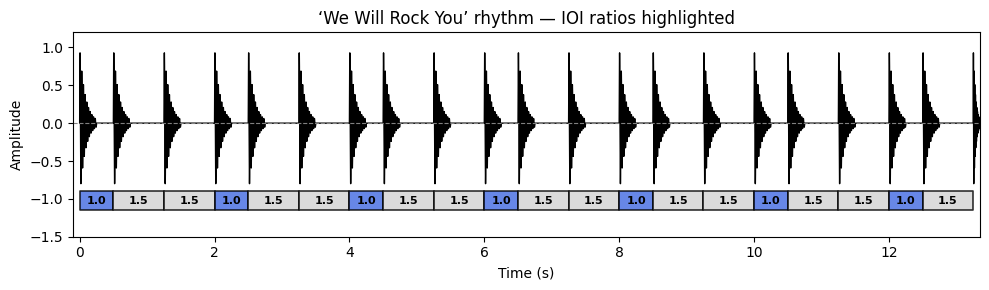

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1) CSV laden ===
df = pd.read_csv("/Users/emilschmiedl/Desktop/Proximity-Funktion/Abbildungen für Poster und Paper/matrizen fürs paper/accelerando copy.csv")

# Nur gültige Onsets und IOIs
onsets = df["onset"].dropna().values
iois = df["IOI"].dropna().values

# === 2) Parameter ===
first_onset = onsets[0] - 0.1
duration = max(onsets) + 0.1
fs = 5000
t = np.linspace(0, duration, int(fs * duration))

wave = np.zeros_like(t)
pulse_len = int(0.25 * fs)
freq = 20
amp = 1.0

# === 3) Wellenform aufbauen ===
for onset in onsets:
    start_idx = np.argmin(np.abs(t - onset))
    end_idx = min(start_idx + pulse_len, len(t))
    x = np.linspace(0, np.pi, end_idx - start_idx)
    pulse = np.sin(x * freq) * np.exp(-3 * (x / np.pi))
    wave[start_idx:end_idx] += pulse * amp

# === 4) Plot vorbereiten ===
plt.figure(figsize=(10, 3))
plt.plot(t, wave, color="black", linewidth=1)
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")

# === 5) IOI-Ratio-Boxen zeichnen ===
min_ioi = np.min(iois)

for i in range(len(iois)):
    start = onsets[i]
    end = onsets[i + 1] if i + 1 < len(onsets) else None
    ratio = round(iois[i] / min_ioi, 2)

    # Farbe abhängig von Ratio-Größe
    if np.isclose(ratio, 1.0, atol=0.1):
        color = "royalblue"
    elif np.isclose(ratio, 2.0, atol=0.2):
        color = "crimson"
    elif ratio > 2.5:
        color = "orange"
    else:
        color = "lightgray"

    if end:
        # Boxhöhe und Position
        y_bottom = -1.15
        box_height = 0.25
        plt.fill_betweenx(
            [y_bottom, y_bottom + box_height],
            start, end,
            color=color, alpha=0.8,
            edgecolor="black", linewidth=1.2
        )

        # Ratio-Wert in die Mitte schreiben
        mid = (start + end) / 2
        plt.text(mid, y_bottom + box_height / 2,
                 f"{ratio:.1f}",
                 ha="center", va="center",
                 fontsize=8, color="black", fontweight="bold")

# === 6) Layout ===
plt.title("‘We Will Rock You’ rhythm — IOI ratios highlighted")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.ylim(-1.5, 1.2)
plt.xlim(first_onset, duration)
plt.tight_layout()
plt.show()


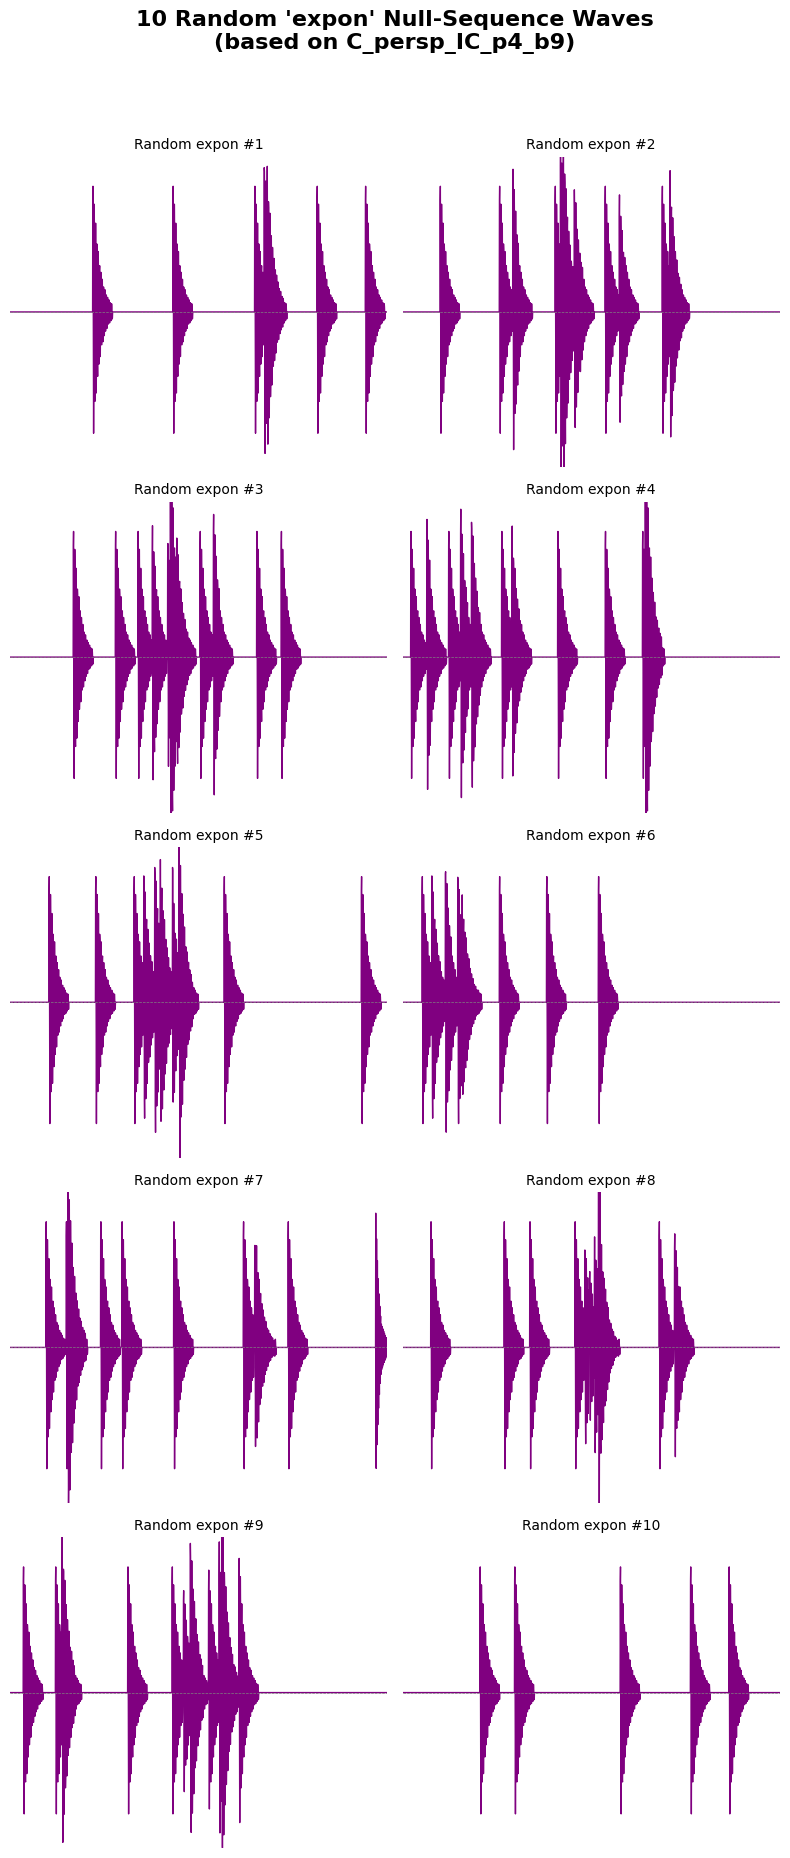

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def generate_null_sequences(iois, num_sequences=10, model="expon", seed=42):
    rng = np.random.default_rng(seed)
    iois = np.asarray(iois, dtype=float)
    n = len(iois)
    mean_ioi = np.mean(iois)
    null_sequences = []

    if model == "expon":
        for _ in range(num_sequences):
            sim = rng.exponential(scale=mean_ioi, size=n)
            null_sequences.append(sim)
    elif model == "uniform":
        for _ in range(num_sequences):
            sim = rng.uniform(np.min(iois), np.max(iois), size=n)
            null_sequences.append(sim)
    else:
        raise ValueError("Nur 'expon' oder 'uniform' unterstützt.")

    return null_sequences


def make_wave(onsets, duration=None, fs=5000, amp=1.0, pulse_len=0.02, freq=30):
    """Erzeugt eine Soundwave-artige Kurve aus Onsets."""
    if duration is None:
        duration = max(onsets) + 0.1
    t = np.linspace(0, duration, int(fs * duration))
    wave = np.zeros_like(t)
    pulse_len_samples = int(pulse_len * fs)

    for onset in onsets:
        idx = np.argmin(np.abs(t - onset))
        end_idx = min(idx + pulse_len_samples, len(t))
        x = np.linspace(0, np.pi, end_idx - idx)
        pulse = np.sin(x * freq) * np.exp(-3 * (x / np.pi))
        wave[idx:end_idx] += pulse * amp
    return t, wave


def plot_random_waves_from_real(file_path, num_sequences=10, model="expon", seed=42):
    """
    Liest echte Sequenz, generiert 10 Nullsequenzen, und plottet sie in 2 Reihen x 5 Spalten.
    """
    df = pd.read_csv(file_path)
    iois = df["IOI"].dropna().values

    # === Onsets berechnen aus IOIs ===
    real_onsets = np.cumsum(iois)
    duration = real_onsets[-1]

    # === Zufallssequenzen generieren ===
    null_sequences = generate_null_sequences(iois, num_sequences=num_sequences, model=model, seed=seed)

    # === Figure ===
    fig, axes = plt.subplots(5, 2, figsize=(8, 18), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, sim_iois in enumerate(null_sequences):
        sim_onsets = np.cumsum(sim_iois)
        t, wave = make_wave(sim_onsets, duration=duration)
        ax = axes[i]
        ax.plot(t, wave, color="purple", linewidth=1)
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.set_xlim(0, duration)
        ax.set_ylim(-1.1, 1.1)
        ax.set_title(f"Random {model} #{i+1}", fontsize=10)
        ax.axis("off")

    fig.suptitle(f"10 Random '{model}' Null-Sequence Waves\n(based on {Path(file_path).stem})", fontsize=16, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()


# === Beispielaufruf ===
plot_random_waves_from_real(
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Bat Carollia perspicillata (C_persp)/C_persp_IC_p4_b9.csv",
    num_sequences=10,
    model="expon",
    seed=42
)


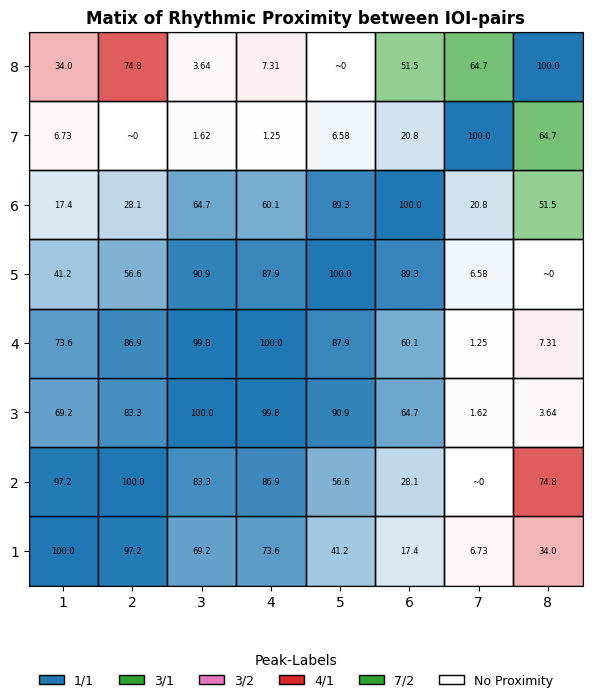

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from fractions import Fraction
from proximitylib.proximity import build_pairwise_proximity_df, param_sets
from pathlib import Path

def plot_peak_matrix_single(file_path, param_choice=0, figsize=(6, 6), save_path=None):
    """
    Einzelne Peakvalue-Matrix (ähnlich wie im Panel).
    Zeigt für eine CSV-Datei mit 'IOI'-Spalte die proximities und Peak-Labels farbcodiert.

    Parameters
    ----------
    file_path : str | Path
        Pfad zur CSV-Datei.
    param_choice : int | str
        Index oder Name aus param_sets.
    figsize : tuple
        Größe der Figure.
    save_path : str | Path | None
        Optionaler Speicherort.
    """
    df = pd.read_csv(file_path)
    iois = df["IOI"].dropna().values
    params = param_sets[param_choice]

    df_pairs, ratios, prox_mat = build_pairwise_proximity_df(iois, params)

    pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
    pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

    # --- Farben vorbereiten ---
    tab10 = plt.cm.tab10.colors
    fixed_colors = {
        "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2], "4/1": tab10[3], "5/1": tab10[4],
        "1/2": tab10[5], "3/2": tab10[6], "5/2": tab10[7], "1/3": tab10[8], "2/3": tab10[9],
        "4/3": (0.5, 0.0, 0.5), "No Proximity": (1, 1, 1)
    }

    all_labels = sorted(set([str(lab) for lab in pivot_labels.values.flatten() if str(lab) != "nan"]))
    label_to_color = {lab: fixed_colors.get(lab, plt.cm.tab20(i % 20)) for i, lab in enumerate(all_labels)}

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    n = len(iois)

    for (i, j), val in np.ndenumerate(pivot_vals.values):
        label = pivot_labels.iloc[i, j]
        base_color = label_to_color.get(label, (0.8, 0.8, 0.8))
        alpha = val / 100 if not np.isnan(val) else 0
        color = (*base_color[:3], alpha)
        ax.add_patch(plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='black'))
        
        if n <= 20 and not np.isnan(val):
            # Intelligentes Runden für Text
            if val <= 1.0:
                display_val = "~0"
            elif val <= 10.0:
                display_val = f"{val:.2f}"
            else:
                display_val = f"{val:.1f}"
            ax.text(j + 0.5, i + 0.5, display_val, ha='center', va='center', fontsize=6, color='black')

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_aspect('equal')
    #ax.set_title(Path(file_path).stem, fontsize=12, fontweight='bold')
    ax.set_title("Matix of Rhythmic Proximity between IOI-pairs", fontsize=12, fontweight='bold')

    # Achsenbeschriftungen
    if len(iois) <= 20:
        ticks = np.arange(n) + 0.5
        labels = np.arange(1, n+1)
    elif len(iois) <= 30:
        step = 3
        ticks = np.arange(0, n, step) + 0.5
        labels = np.arange(1, n+1, step)
    else:
        step = 10
        ticks = np.arange(0, n, step) + 0.5
        labels = np.arange(1, n+1, step)

    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # --- Legende ---
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=label_to_color[lab], edgecolor='black') for lab in all_labels]
    fig.legend(handles, all_labels, loc='lower center', ncol=min(len(all_labels), 6),
               fontsize=9, title="Peak-Labels", frameon=False)

    plt.tight_layout(rect=[0, 0.1, 1, 1])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Matrix gespeichert unter: {save_path}")

    plt.show()


# --- Beispielaufruf ---
plot_peak_matrix_single(
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp/KWA5.csv",
    param_choice=3,
    figsize=(7, 7),
    save_path=None
)


✅ Panel gespeichert unter: miii.png


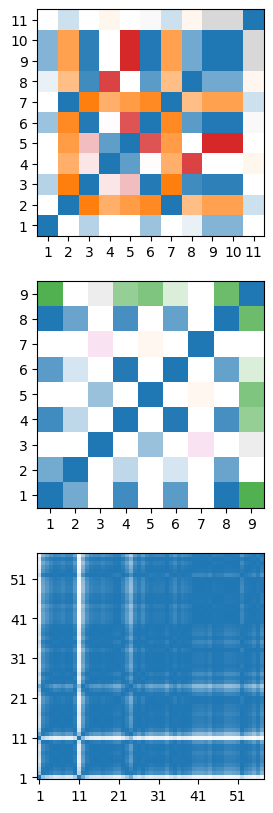

In [108]:
# matrizen
from pathlib import Path
import sys

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))  # geht eine Ebene hoch

import importlib
import proximitylib.proximity as prox
from tabulate import tabulate
importlib.reload(prox)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from fractions import Fraction
from proximitylib.proximity import build_pairwise_proximity_df, proximity_max_freq_gaussian_table, param_sets
import math

def panel_peak_matrices_2rows(file_paths, param_choice=0, figsize=(18, 30), save_path=None):
    """
    Paperreifes Panel mit Peakvalue-Matrizen für mehrere Dateien in 2 Reihen.

    Parameters
    ----------
    file_paths : list of str | Path
        Liste von vollständigen Pfaden zu CSV-Dateien mit 'IOI'-Spalte.
    param_choice : int | str
        Param-Dict aus param_sets.
    figsize : tuple
        Figurgröße.
    save_path : str | Path | None
        Optionaler Speicherort.
    """
    n_files = len(file_paths)
    n_cols = math.ceil(n_files / 3)
    n_rows = 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=False)
    axes = axes.flatten()

    params = param_sets[param_choice]

    # Farben für Peak-Labels (Basisfarben)
    tab10 = plt.cm.tab10.colors
    fixed_colors = {
        "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2], "4/1": tab10[3], "5/1": tab10[4],
        "1/2": tab10[5], "3/2": tab10[6], "5/2": tab10[7], "1/3": tab10[8], "2/3": tab10[9],
        "4/3": (0.5, 0.0, 0.5)
    }

    # -------------------------
    # Alle Peak-Labels über alle Dateien sammeln (nur tatsächlich genutzte Labels)
    # -------------------------
    all_peak_labels = set()
    for path in file_paths:
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        df_pairs, _, _ = build_pairwise_proximity_df(iois, params)
        # explizit als string, NaN/None ausschließen
        labels_here = pd.Series(df_pairs["peak_label"].astype(str)).dropna().unique()
        # evtl. leere Strings entfernen
        labels_here = [lab for lab in labels_here if lab != "" and lab.lower() != "nan"]
        all_peak_labels.update(labels_here)
    all_peak_labels = sorted(all_peak_labels)

    # Falls du möchtest, dass "Keine Proximity" immer dabei ist, sicherstellen:
    if "No Proximity" not in all_peak_labels:
        all_peak_labels.insert(0, "No Proximity")
    
    # Farben zuordnen
    label_to_color = {}
    for idx, lab in enumerate(all_peak_labels):
        if lab == "No Proximity":
            label_to_color[lab] = (1,1,1)  # weiß
        elif lab in fixed_colors:
            label_to_color[lab] = fixed_colors[lab]
        else:
            color = plt.cm.tab20(idx % 20)
            label_to_color[lab] = color

    # Dateien plotten
    for ax, path in zip(axes, file_paths):
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        n = len(iois)

        df_pairs, ratios, prox_mat = build_pairwise_proximity_df(iois, params)
        pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
        pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

        for (i, j), val in np.ndenumerate(pivot_vals.values):
            label = pivot_labels.iloc[i, j]
            base_color = label_to_color.get(label, (0.8, 0.8, 0.8))
            alpha = val / 100 if not np.isnan(val) else 0
            color = (*base_color[:3], alpha)
            ax.add_patch(plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='none'))
            if n <= 2 and not np.isnan(val):
                ax.text(j+0.5, i+0.5, f"{float(val.item()):.1f}", ha='center', va='center', fontsize=6, color="black")

        ax.set_xlim(0, n)
        ax.set_ylim(0, n)
        ax.set_aspect('equal')

        if len(iois) <= 29:
            ax.set_xticks(np.arange(n) + 0.5)
            ax.set_yticks(np.arange(n) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1))
            ax.set_yticklabels(np.arange(1, n+1))
        elif len(iois) <= 30:
            step = 3
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))
        else: 
            step = 10
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))

    # Achsen für leere Plätze deaktivieren
    for ax in axes[n_files:]:
        ax.axis('off')

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Panel gespeichert unter: {save_path}")

    plt.show()

files = [
    "../data/ergebnis-tabellen/heterochrony-1-2/heterochrony-1-2_jitter-0050_04.csv",
    "../data/ergebnis-tabellen/isochrony_small-jitter/isochrony_jitter-0001_04.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/random_exponential_03.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_drift.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/jitter_middle-0050_02.csv",
    "../data/ergebnis-tabellen/heterochrony-2-3/heterochrony-2-3_jitter-0050_06.csv",
    "../data/ergebnis-tabellen/isochrony_big-jitter/isochrony_jitter-0050_03.csv",
    "../data/ergebnis-tabellen/random uniform/random_uniform_04.csv",
    "../data/ergebnis-tabellen/accelerando/accelerando.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/tempo_shift_onlyioi-jitter-0050_06.csv"
]

animals = [
    "../data/Bat Carollia perspicillata (C_persp)/C_persp_IC_p4_b9.csv",
    "../data/Kwa-Sounds Scorpaena spp/KWA10.csv",
    "../data/Sperm whale Physeter macrocephalus (sw)/sw114a002_coda_02.xls.csv"
]

panel_peak_matrices_2rows(animals, param_choice=3, figsize=(18, 10), save_path="miii.png")


✅ Panel gespeichert unter: miii.png


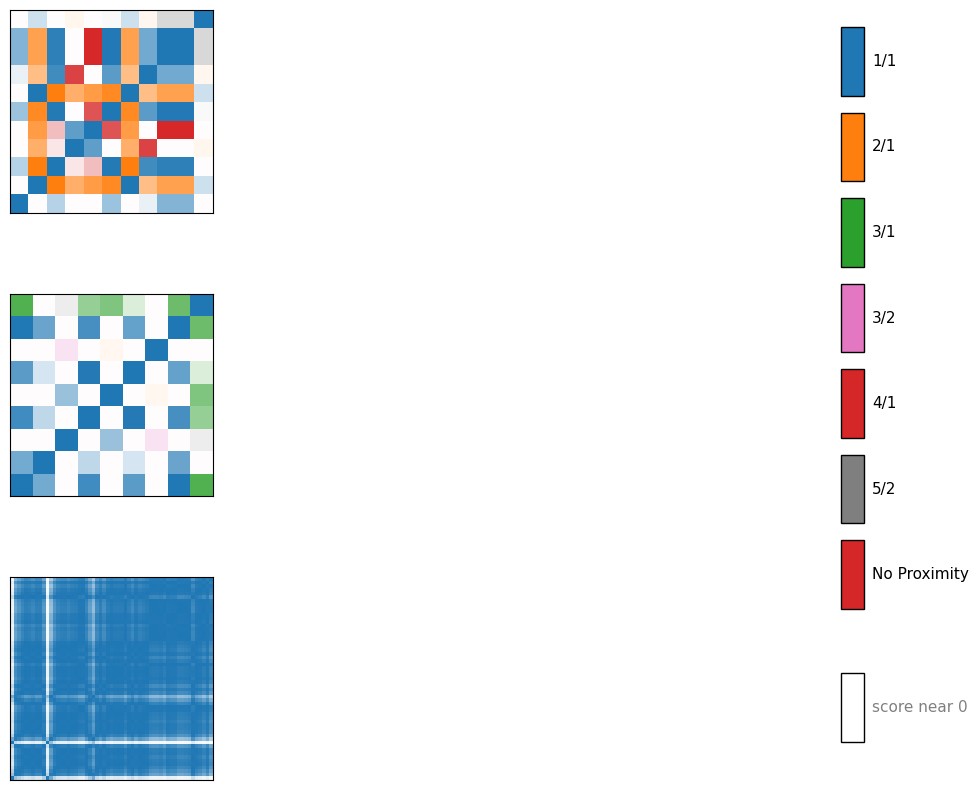

In [113]:
def panel_peak_matrices_2rows(file_paths, param_choice=0, figsize=(18, 30), save_path=None):
    import matplotlib.gridspec as gridspec

    n_files = len(file_paths)
    n_cols = math.ceil(n_files / 3)
    n_rows = 3

    # Haupt-Grid + rechte Legende
    fig = plt.figure(figsize=figsize)
    outer = gridspec.GridSpec(1, 2, width_ratios=[15, 1], wspace=0.2, figure=fig)
    grid = gridspec.GridSpecFromSubplotSpec(n_rows, n_cols, subplot_spec=outer[0], wspace=0.3, hspace=0.4)
    ax_legend = fig.add_subplot(outer[1])
    ax_legend.axis("off")

    # Subplots
    axes = [fig.add_subplot(grid[i, j]) for i in range(n_rows) for j in range(n_cols)]
    params = param_sets[param_choice]

    # --- Farben für Peak-Labels ---
    tab10 = plt.cm.tab10.colors
    fixed_colors = {
        "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2], "4/1": tab10[3], "5/1": tab10[4],
        "1/2": tab10[5], "3/2": tab10[6], "1/3": tab10[8], "2/3": tab10[9],
        "4/3": (0.5, 0.0, 0.5), "Score near 0": (1, 1, 1), "5/2": tab10[7]
    }

    # --- Alle Labels sammeln ---
    all_peak_labels = set()
    for path in file_paths:
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        df_pairs, _, _ = build_pairwise_proximity_df(iois, params)
        labs = [lab for lab in pd.Series(df_pairs["peak_label"].astype(str)).dropna().unique()
                if lab and lab.lower() != "nan"]
        all_peak_labels.update(labs)
    all_peak_labels = sorted(all_peak_labels)
    if "No Proximity" not in all_peak_labels:
        all_peak_labels.insert(0, "Score near 0")

    # --- Farbzuordnung ---
    label_to_color = {}
    for idx, lab in enumerate(all_peak_labels):
        if lab == "Score near 0":
            label_to_color[lab] = (1, 1, 1)
        elif lab in fixed_colors:
            label_to_color[lab] = fixed_colors[lab]
        else:
            label_to_color[lab] = plt.cm.tab20(idx % 20)

    # --- Matrizen zeichnen ---
    for ax, path in zip(axes, file_paths):
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        n = len(iois)
        df_pairs, _, _ = build_pairwise_proximity_df(iois, params)
        pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
        pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

        for (i, j), val in np.ndenumerate(pivot_vals.values):
            label = pivot_labels.iloc[i, j]
            base = label_to_color.get(label, (0.8, 0.8, 0.8))
            alpha = val / 100 if not np.isnan(val) else 0
            ax.add_patch(plt.Rectangle([j, i], 1, 1, facecolor=(*base[:3], alpha), edgecolor='none'))
        ax.set_xlim(0, n)
        ax.set_ylim(0, n)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])

    # --- Legende rechts ---
    y0 = 1.0
    y_step = 1.0 / (len(all_peak_labels) + 2)
    box_h = y_step * 0.8
    for i, lab in enumerate(all_peak_labels):
        y = y0 - (i + 1) * y_step
        color = label_to_color[lab]
        rect = plt.Rectangle((0.1, y), 0.3, box_h, facecolor=color, edgecolor='black', transform=ax_legend.transAxes)
        ax_legend.add_patch(rect)
        ax_legend.text(0.5, y + box_h / 2, lab, va='center', ha='left', fontsize=11)

    # --- Weißes Feld "Score near 0" ---
    y_bottom = 0.05
    rect = plt.Rectangle((0.1, y_bottom), 0.3, box_h, facecolor='white', edgecolor='black', transform=ax_legend.transAxes)
    ax_legend.add_patch(rect)
    ax_legend.text(0.5, y_bottom + box_h / 2, "score near 0", va='center', ha='left', fontsize=11, color='gray')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Panel gespeichert unter: {save_path}")

    plt.show()

animals = [
    "../data/Bat Carollia perspicillata (C_persp)/C_persp_IC_p4_b9.csv",
    "../data/Kwa-Sounds Scorpaena spp/KWA10.csv",
    "../data/Sperm whale Physeter macrocephalus (sw)/sw114a002_coda_02.xls.csv"
]

panel_peak_matrices_2rows(animals, param_choice=3, figsize=(18, 10), save_path="miii.png")


✅ Legende gespeichert unter: ratio_legend.png


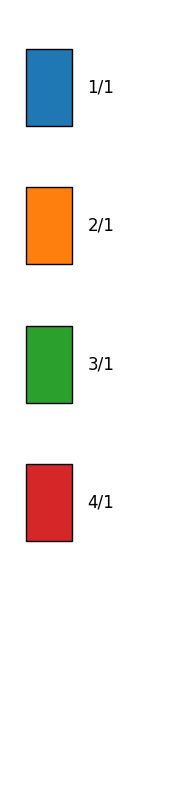

In [125]:
import matplotlib.pyplot as plt

def simple_ratio_legend(save_path=None):
    """
    Erstellt eine vertikale Legende mit den Haupt-Ratio-Farben:
    1:1, 2:1, 3:1, 4:1 und 'score near 0'.
    """
    ratios = ["1/1", "2/1", "3/1", "4/1"] #, "score near 0"

    # Farben (wie in Proximity-Plots)
    tab10 = plt.cm.tab10.colors
    colors = {
        "1/1": tab10[0],
        "2/1": tab10[1],
        "3/1": tab10[2],
        "4/1": tab10[3]
    }
#        "score near 0": (1, 1, 1),  # weiß
    # Figure vorbereiten
    fig, ax = plt.subplots(figsize=(2, 10))
    ax.axis("off")

    y0 = 0.85
    y_step = 0.18
    box_h = 0.1
    for i, ratio in enumerate(ratios):
        y = y0 - i * y_step
        rect = plt.Rectangle((0.1, y), 0.3, box_h,
                             facecolor=colors[ratio], edgecolor='black',
                             transform=ax.transAxes)
        ax.add_patch(rect)
        ax.text(0.5, y + box_h / 2, ratio,
                va='center', ha='left', fontsize=12,
                color='black')  # schwarze Schrift auch für near 0

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"✅ Legende gespeichert unter: {save_path}")

    plt.show()


# Beispiel-Aufruf
if __name__ == "__main__":
    simple_ratio_legend("ratio_legend.png")


✅ Legende gespeichert unter: ratio_legend_grid.png


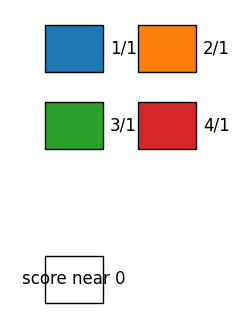

In [120]:
import matplotlib.pyplot as plt

def ratio_legend_grid(save_path=None):
    """
    Legende mit 3 Reihen x 2 Spalten für 1/1, 2/1, 3/1, 4/1 und
    eine weiße Box für 'score near 0' linksbündig darunter.
    """
    tab10 = plt.cm.tab10.colors
    colors = {
        "1/1": tab10[0],
        "2/1": tab10[1],
        "3/1": tab10[2],
        "4/1": tab10[3],
    }

    labels = list(colors.keys())

    fig, ax = plt.subplots(figsize=(3, 4))
    ax.axis("off")

    # --- Layout-Parameter ---
    n_cols = 2
    box_w, box_h = 0.25, 0.15

    # X-Positionen der beiden Spalten
    x_positions = [0.15, 0.55]
    # Y-Positionen für obere zwei Reihen mit mehr Abstand
    y_positions = [0.8, 0.55, 0.3]  # Platz zwischen den Reihen vergrößert

    # --- Vier farbige Boxen (2x2 Grid) ---
    for i, label in enumerate(labels):
        row = i // n_cols
        col = i % n_cols
        x = x_positions[col]
        y = y_positions[row]
        rect = plt.Rectangle((x, y), box_w, box_h,
                             facecolor=colors[label], edgecolor='black',
                             transform=ax.transAxes)
        ax.add_patch(rect)
        ax.text(x + box_w + 0.03, y + box_h / 2, label,
                va='center', ha='left', fontsize=12, color='black')

    # --- Weißes Feld für "score near 0" linksbündig ---
    rect_white = plt.Rectangle((x_positions[0], 0.05), box_w, box_h,
                               facecolor='white', edgecolor='black',
                               transform=ax.transAxes)
    ax.add_patch(rect_white)
    ax.text(x_positions[0] + box_w / 2, 0.05 + box_h / 2, "score near 0",
            va='center', ha='center', fontsize=12, color='black')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)
        print(f"✅ Legende gespeichert unter: {save_path}")

    plt.show()


# Beispiel-Aufruf
if __name__ == "__main__":
    ratio_legend_grid("ratio_legend_grid.png")


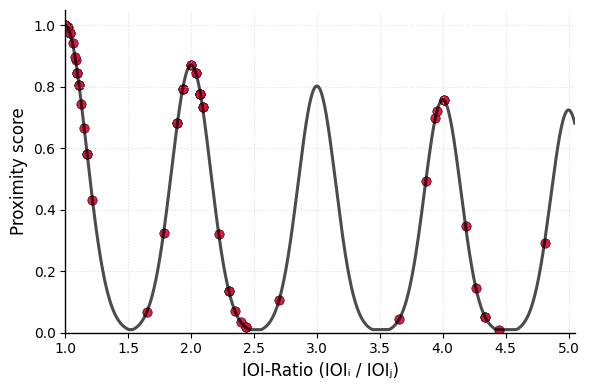

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from proximitylib.proximity import (
    proximity_max_freq_gaussian_table,
    build_pairwise_proximity_df,
    param_sets
)

def simple_proximity_plot(file_path, param_choice=3, figsize=(6, 4), save_path=None):
    """
    Ästhetisch reduzierte Darstellung der Proximity-Funktion mit roten Punkten
    für die IOI-Ratios der realen Sequenz.
    """
    # === Datei laden ===
    df = pd.read_csv(file_path)
    iois = df["IOI"].dropna().values
    params = prox.param_sets[param_choice]

    # === Ratio-Bereich und Proximity-Funktion ===
    df_pairs, ratios, prox_max = build_pairwise_proximity_df(iois, params)
    x_min = max(1.0, df_pairs["ratio"].min() * 0.95)
    x_max = df_pairs["ratio"].max() * 1.05
    x_range = np.linspace(x_min, x_max, 2000)
    y_curve, _ = proximity_max_freq_gaussian_table(x_range, **params)

    # === Plot ===
    fig, ax = plt.subplots(figsize=figsize)

    # Proximity-Kurve (hellgrau)
    ax.plot(x_range, y_curve, color="black", linewidth=2.2, alpha=0.7, label="Proximity-Funktion")

    # Rote Punkte (IOI-Ratios)
    ax.scatter(df_pairs["ratio"], df_pairs["prox_value"], s=45, color="crimson", alpha=0.8, edgecolor="black", linewidth=0.3, label="IOI-Ratios")

    # === Achsen und Stil ===
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("IOI-Ratio (IOIᵢ / IOIⱼ)", fontsize=12)
    ax.set_ylabel("Proximity score", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True, linestyle=":", color="lightgray", alpha=0.7)

    # Spines dezenter
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_linewidth(1)
    ax.spines["left"].set_linewidth(1)

    # Hintergrund & Layout
    ax.set_facecolor("white")
    plt.tight_layout()

    # Optional speichern
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Plot gespeichert unter: {save_path}")

    plt.show()


# === Beispielaufruf ===
simple_proximity_plot(
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Bat Carollia perspicillata (C_persp)/C_persp_IC_p4_b9.csv",
    param_choice=2,
    figsize=(6, 4),
    save_path=None
)

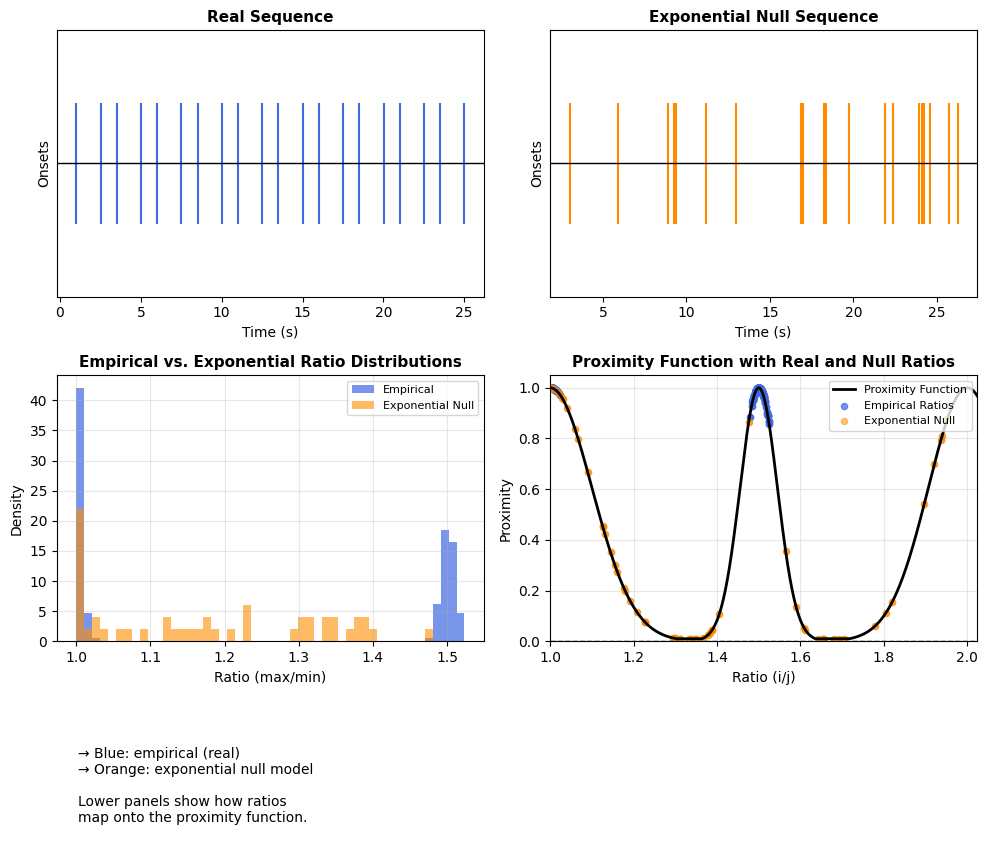

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from proximitylib.proximity import (
    build_pairwise_proximity_df,
    proximity_max_freq_gaussian_table,
    param_sets
)

def plot_sequence_panel_with_expon_onsets(file_path, param_choice=3, seed=42):
    """
    Zeigt eine Übersicht für eine einzelne Sequenz:
    ┌───────────────┬────────────────────┐
    │ (1) Real Onsets (blau)  │ (2) Expon. Null (orange) │
    ├───────────────┬────────────────────┤
    │ (3) Ratio-Hist │ (4) Proximity-Kurve │
    ├───────────────┬────────────────────┤
    │ (5) Leerer Bereich (weiß) │ (6) Leerer Bereich (weiß) │
    └───────────────┴────────────────────┘
    """
    rng = np.random.default_rng(seed)
    df = pd.read_csv(file_path)
    iois = df["IOI"].dropna().values
    onsets_real = np.cumsum(iois)
    params = param_sets[param_choice]

    # --- Nullsequenz ---
    iois_null = rng.exponential(scale=np.mean(iois), size=len(iois))
    onsets_null = np.cumsum(iois_null)

    # --- Ratios ---
    df_pairs, ratios, _ = build_pairwise_proximity_df(iois, params)
    x_min = 1
    x_max = np.percentile(df_pairs["ratio"], 99)
    x_range = np.linspace(x_min, x_max + 1, 2000)
    y_curve, _ = proximity_max_freq_gaussian_table(x_range, **params)

    # --- Ratios Null ---
    ratios_exp = np.maximum(iois_null[:, None], iois_null[None, :]) / np.minimum(iois_null[:, None], iois_null[None, :])
    ratios_exp_flat = ratios_exp.flatten()
    prox_exp_flat, _ = proximity_max_freq_gaussian_table(ratios_exp_flat, **params)
    r_real_flat = (np.maximum(iois[:, None], iois[None, :]) / np.minimum(iois[:, None], iois[None, :])).flatten()

    # --- Figure ---
    fig, axs = plt.subplots(3, 2, figsize=(10, 9), height_ratios=[1, 1, 0.5])
    axs = axs.flatten()

    # 1) Real Onsets
    axs[0].eventplot(onsets_real, color='royalblue', lineoffsets=0, linelengths=1)
    axs[0].axhline(0, color='black', lw=1)
    axs[0].set_xlabel("Time (s)")
    axs[0].set_ylabel("Onsets")
    axs[0].set_yticks([])
    axs[0].grid(False)
    axs[0].set_title("Real Sequence", fontsize=11, weight="bold")

    # 2) Exponential Null Onsets
    axs[1].eventplot(onsets_null, color='darkorange', lineoffsets=0, linelengths=1)
    axs[1].axhline(0, color='black', lw=1)
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Onsets")
    axs[1].set_yticks([])
    axs[1].grid(False)
    axs[1].set_title("Exponential Null Sequence", fontsize=11, weight="bold")

    # 3) Ratio-Histogramm
    bins_lin = np.linspace(x_min, x_max, 50)
    axs[2].hist(r_real_flat, bins=bins_lin, density=True, alpha=0.7, color='royalblue', label='Empirical')
    axs[2].hist(ratios_exp_flat, bins=bins_lin, density=True, alpha=0.6, color='darkorange', label='Exponential Null')
    axs[2].set_xlabel("Ratio (max/min)")
    axs[2].set_ylabel("Density")
    axs[2].grid(alpha=0.3)
    axs[2].legend(fontsize=8)
    axs[2].set_title("Empirical vs. Exponential Ratio Distributions", fontsize=11, weight="bold")

    # 4) Proximity-Funktion
    axs[3].plot(x_range, y_curve, color='black', lw=2, label="Proximity Function")
    axs[3].scatter(r_real_flat, proximity_max_freq_gaussian_table(r_real_flat, **params)[0], 
                   s=20, color='royalblue', alpha=0.7, label="Empirical Ratios")
    axs[3].scatter(ratios_exp_flat, prox_exp_flat, s=20, color='darkorange', alpha=0.5, label="Exponential Null")
    axs[3].axhline(0, color='black', lw=1, linestyle='--')
    axs[3].set_xlabel("Ratio (i/j)")
    axs[3].set_ylabel("Proximity")
    axs[3].set_xlim(x_min, x_max + 0.5)
    axs[3].set_ylim(0, 1.05)
    axs[3].grid(alpha=0.3)
    axs[3].legend(fontsize=8, loc='upper right')
    axs[3].set_title("Proximity Function with Real and Null Ratios", fontsize=11, weight="bold")

    # 5 & 6) Weißer Erklärungsbereich
    for ax in axs[4:]:
        ax.set_facecolor("white")
        ax.axis('off')

    # Optional: Platz für Text oder Annotation
    axs[4].text(0.05, 0.8,
                "→ Blue: empirical (real)\n"
                "→ Orange: exponential null model\n\n"
                "Lower panels show how ratios\n"
                "map onto the proximity function.",
                fontsize=10, va="top")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


# === Beispielaufruf ===
file_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-2-3_jitter-0005_09.csv"
plot_sequence_panel_with_expon_onsets(file_path, param_choice=3)


✅ Panel gespeichert unter: miii.png


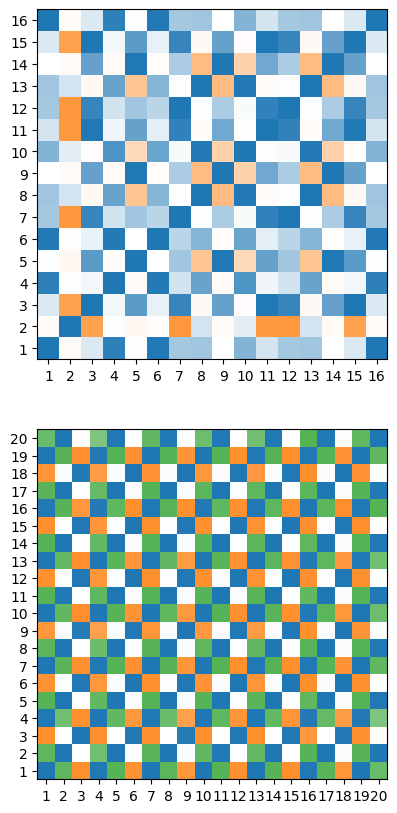

In [40]:
# matrizen
from pathlib import Path
import sys

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))  # geht eine Ebene hoch

import importlib
import proximitylib.proximity as prox
from tabulate import tabulate
importlib.reload(prox)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from fractions import Fraction
from proximitylib.proximity import build_pairwise_proximity_df, proximity_max_freq_gaussian_table, param_sets
import math

def panel_peak_matrices_2rows(file_paths, param_choice=0, figsize=(18, 30), save_path=None):
    """
    Paperreifes Panel mit Peakvalue-Matrizen für mehrere Dateien in 2 Reihen.

    Parameters
    ----------
    file_paths : list of str | Path
        Liste von vollständigen Pfaden zu CSV-Dateien mit 'IOI'-Spalte.
    param_choice : int | str
        Param-Dict aus param_sets.
    figsize : tuple
        Figurgröße.
    save_path : str | Path | None
        Optionaler Speicherort.
    """
    n_files = len(file_paths)
    n_cols = math.ceil(n_files / 2)
    n_rows = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=False)
    axes = axes.flatten()

    params = param_sets[param_choice]

    # Farben für Peak-Labels (Basisfarben)
    tab10 = plt.cm.tab10.colors
    fixed_colors = {
        "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2], "4/1": tab10[3], "5/1": tab10[4],
        "1/2": tab10[5], "3/2": tab10[6], "5/2": tab10[7], "1/3": tab10[8], "2/3": tab10[9],
        "4/3": (0.5, 0.0, 0.5)
    }

    # -------------------------
    # Alle Peak-Labels über alle Dateien sammeln (nur tatsächlich genutzte Labels)
    # -------------------------
    all_peak_labels = set()
    for path in file_paths:
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        df_pairs, _, _ = build_pairwise_proximity_df(iois, params)
        # explizit als string, NaN/None ausschließen
        labels_here = pd.Series(df_pairs["peak_label"].astype(str)).dropna().unique()
        # evtl. leere Strings entfernen
        labels_here = [lab for lab in labels_here if lab != "" and lab.lower() != "nan"]
        all_peak_labels.update(labels_here)
    all_peak_labels = sorted(all_peak_labels)

    # Falls du möchtest, dass "Keine Proximity" immer dabei ist, sicherstellen:
    if "No Proximity" not in all_peak_labels:
        all_peak_labels.insert(0, "No Proximity")
    
    # Farben zuordnen
    label_to_color = {}
    for idx, lab in enumerate(all_peak_labels):
        if lab == "No Proximity":
            label_to_color[lab] = (1,1,1)  # weiß
        elif lab in fixed_colors:
            label_to_color[lab] = fixed_colors[lab]
        else:
            color = plt.cm.tab20(idx % 20)
            label_to_color[lab] = color

    # Dateien plotten
    for ax, path in zip(axes, file_paths):
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        n = len(iois)

        df_pairs, ratios, prox_mat = build_pairwise_proximity_df(iois, params)
        pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
        pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

        for (i, j), val in np.ndenumerate(pivot_vals.values):
            label = pivot_labels.iloc[i, j]
            base_color = label_to_color.get(label, (0.8, 0.8, 0.8))
            alpha = val / 100 if not np.isnan(val) else 0
            color = (*base_color[:3], alpha)
            ax.add_patch(plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='none'))
            if n <= 2 and not np.isnan(val):
                ax.text(j+0.5, i+0.5, f"{float(val.item()):.1f}", ha='center', va='center', fontsize=6, color="black")

        ax.set_xlim(0, n)
        ax.set_ylim(0, n)
        ax.set_aspect('equal')

        if len(iois) <= 29:
            ax.set_xticks(np.arange(n) + 0.5)
            ax.set_yticks(np.arange(n) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1))
            ax.set_yticklabels(np.arange(1, n+1))
        elif len(iois) <= 30:
            step = 3
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))
        else: 
            step = 10
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))

    # Achsen für leere Plätze deaktivieren
    for ax in axes[n_files:]:
        ax.axis('off')

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Panel gespeichert unter: {save_path}")

    plt.show()

files = [
    "../data/ergebnis-tabellen/heterochrony-1-2/heterochrony-1-2_jitter-0050_04.csv",
    "../data/ergebnis-tabellen/isochrony_small-jitter/isochrony_jitter-0001_04.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/random_exponential_03.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_drift.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/jitter_middle-0050_02.csv",
    "../data/ergebnis-tabellen/heterochrony-2-3/heterochrony-2-3_jitter-0050_06.csv",
    "../data/ergebnis-tabellen/isochrony_big-jitter/isochrony_jitter-0050_03.csv",
    "../data/ergebnis-tabellen/random uniform/random_uniform_04.csv",
    "../data/ergebnis-tabellen/accelerando/accelerando.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/tempo_shift_onlyioi-jitter-0050_06.csv"
]

animals = [
    "../data/Bat Saccopteryx bilineata (S_bil)/S_bil_IC_p21_2 copy.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-1-3-2_jitter-0010_08.csv"
]

panel_peak_matrices_2rows(animals, param_choice=2, figsize=(18, 10), save_path="miii.png")


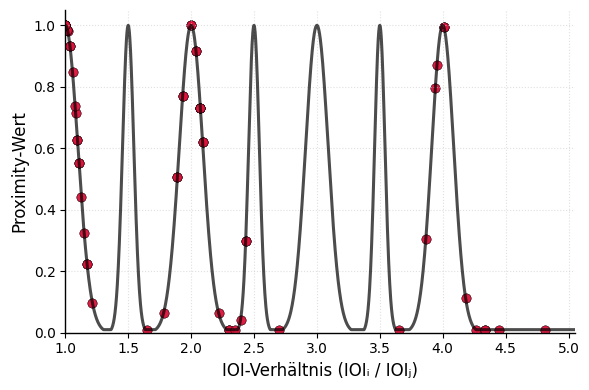

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from proximitylib.proximity import (
    proximity_max_freq_gaussian_table,
    build_pairwise_proximity_df,
    param_sets
)

def simple_proximity_plot(file_path, param_choice=3, figsize=(6, 4), save_path=None):
    """
    Ästhetisch reduzierte Darstellung der Proximity-Funktion mit roten Punkten
    für die IOI-Ratios der realen Sequenz.
    """
    # === Datei laden ===
    df = pd.read_csv(file_path)
    iois = df["IOI"].dropna().values
    params = param_sets[param_choice]

    # === Ratio-Bereich und Proximity-Funktion ===
    df_pairs, ratios, prox_max = build_pairwise_proximity_df(iois, params)
    x_min = max(1.0, df_pairs["ratio"].min() * 0.95)
    x_max = df_pairs["ratio"].max() * 1.05
    x_range = np.linspace(x_min, x_max, 2000)
    y_curve, _ = proximity_max_freq_gaussian_table(x_range, **params)

    # === Plot ===
    fig, ax = plt.subplots(figsize=figsize)

    # Proximity-Kurve (hellgrau)
    ax.plot(x_range, y_curve, color="black", linewidth=2.2, alpha=0.7, label="Proximity-Funktion")

    # Rote Punkte (IOI-Ratios)
    ax.scatter(df_pairs["ratio"], df_pairs["prox_value"], s=45, color="crimson", alpha=0.8, edgecolor="black", linewidth=0.3, label="IOI-Ratios")

    # === Achsen und Stil ===
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("IOI-Verhältnis (IOIᵢ / IOIⱼ)", fontsize=12)
    ax.set_ylabel("Proximity-Wert", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True, linestyle=":", color="lightgray", alpha=0.7)

    # Spines dezenter
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_linewidth(1)
    ax.spines["left"].set_linewidth(1)

    # Hintergrund & Layout
    ax.set_facecolor("white")
    plt.tight_layout()

    # Optional speichern
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Plot gespeichert unter: {save_path}")

    plt.show()


# === Beispielaufruf ===
simple_proximity_plot(
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Bat Carollia perspicillata (C_persp)/C_persp_IC_p4_b9.csv",
    param_choice=3,
    figsize=(6, 4),
    save_path=None
)


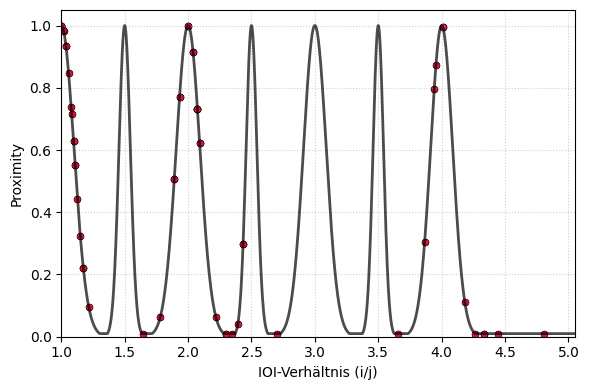

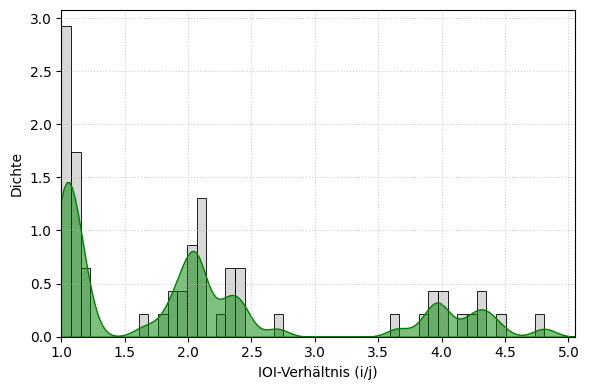

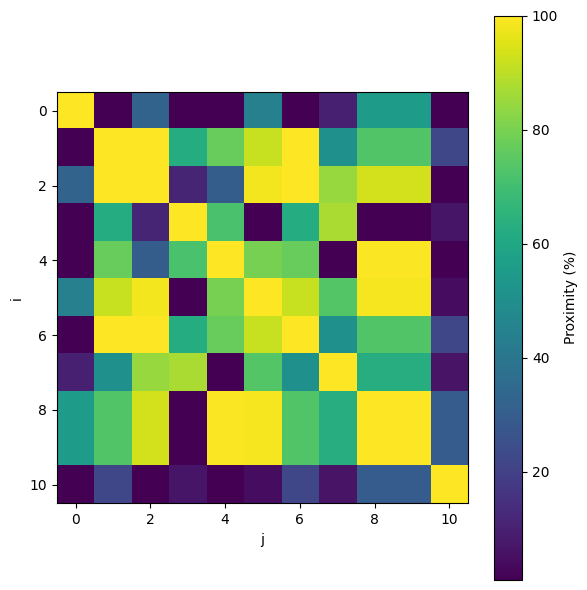

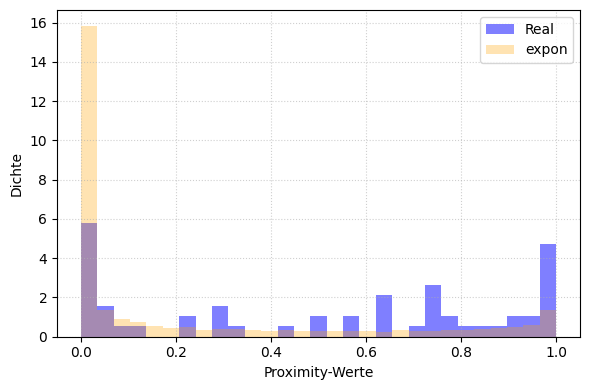

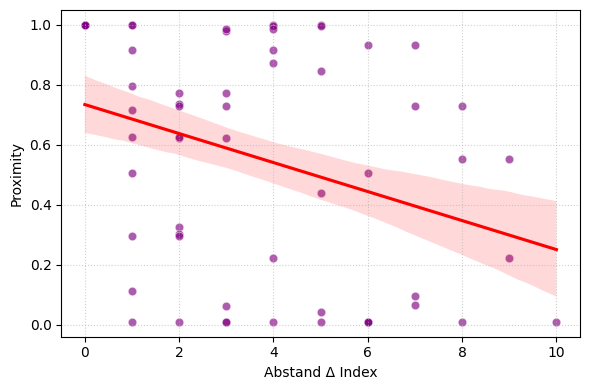

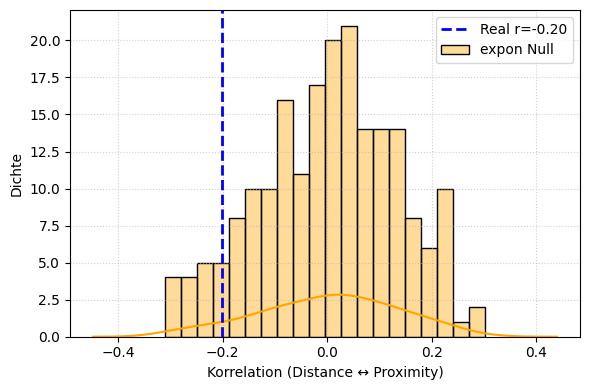

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from proximitylib.proximity import (
    build_pairwise_proximity_df,
    proximity_max_freq_gaussian_table,
    param_sets,
    analyze_single_sequence
)

# ===============================================================
#  Vorbereitung: IOIs laden & Grunddaten vorbereiten
# ===============================================================

def prepare_sequence_data(file_path, param_choice=3, num_sequences=200, seed=42, models=("expon",)):
    df = pd.read_csv(file_path)
    iois = df["IOI"].dropna().values
    params = param_sets[param_choice]

    df_pairs, ratios, prox_mat = build_pairwise_proximity_df(iois, params)
    results = analyze_single_sequence(iois, params, num_sequences=num_sequences, plot=False, seed=seed, models=models)
    return iois, df_pairs, results, params

# ===============================================================
#  Einzelplots
# ===============================================================

def plot_proximity_function(df_pairs, params, figsize=(6,4)):
    x_min = max(1.0, df_pairs["ratio"].min()*0.95)
    x_max = df_pairs["ratio"].max()*1.05
    x_range = np.linspace(x_min, x_max, 2000)
    y_curve, _ = proximity_max_freq_gaussian_table(x_range, **params)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(x_range, y_curve, color="black", lw=2, alpha=0.7)
    ax.scatter(df_pairs["ratio"], df_pairs["prox_value"], s=25, color="crimson", edgecolor="black", lw=0.3)
    ax.set_xlabel("IOI-Verhältnis (i/j)")
    ax.set_ylabel("Proximity")
    ax.grid(True, ls=":", alpha=0.6)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

def plot_ratio_distribution(df_pairs, figsize=(6,4)):
    x_min = max(1.0, df_pairs["ratio"].min()*0.95)
    x_max = df_pairs["ratio"].max()*1.05
    fig, ax = plt.subplots(figsize=figsize)
    sns.histplot(df_pairs["ratio"], bins=50, stat="density", color="gray", alpha=0.3, ax=ax)
    sns.kdeplot(df_pairs["ratio"], fill=True, color="green", alpha=0.5, bw_adjust=0.2, ax=ax)
    ax.set_xlabel("IOI-Verhältnis (i/j)")
    ax.set_ylabel("Dichte")
    ax.grid(True, ls=":", alpha=0.6)
    ax.set_xlim(x_min, x_max)
    plt.tight_layout()
    plt.show()

def plot_proximity_matrix(df_pairs, params, figsize=(6,6)):
    pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot_vals, cmap="viridis", origin="upper")
    plt.colorbar(im, ax=ax, label="Proximity (%)")
    ax.set_xlabel("j")
    ax.set_ylabel("i")
    plt.tight_layout()
    plt.show()

def plot_histogram_real_vs_null(results, figsize=(6,4)):
    colors = {"Real":"blue", "expon":"orange", "uniform":"gray"}
    fig, ax = plt.subplots(figsize=figsize)
    bins = np.linspace(0,1,30)
    ax.hist(results["proximity_real"], bins=bins, density=True, color="blue", alpha=0.5, label="Real")
    for model, vals in results["null_proximities"].items():
        ax.hist(vals, bins=bins, density=True, alpha=0.3, color=colors.get(model,"gray"), label=f"{model}")
    ax.set_xlabel("Proximity-Werte")
    ax.set_ylabel("Dichte")
    ax.grid(True, ls=":", alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_distance_proximity(df_pairs, figsize=(6,4)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(x=df_pairs["distance"], y=df_pairs["prox_value"], alpha=0.4, color="purple", ax=ax)
    sns.regplot(x=df_pairs["distance"], y=df_pairs["prox_value"], scatter=False, color="red", ax=ax)
    ax.set_xlabel("Abstand Δ Index")
    ax.set_ylabel("Proximity")
    ax.grid(True, ls=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_distance_proximity_corr(results, figsize=(6,4)):
    colors = {"expon":"orange", "uniform":"gray"}
    fig, ax = plt.subplots(figsize=figsize)
    for model, vals in results["distance_corr_nulls"].items():
        sns.histplot(vals, bins=20, color=colors.get(model,"gray"), alpha=0.4, label=f"{model} Null", ax=ax)
        sns.kdeplot(vals, color=colors.get(model,"gray"), ax=ax)
    ax.axvline(results["distance_corr_real"], color="blue", ls="--", lw=2, label=f"Real r={results['distance_corr_real']:.2f}")
    ax.set_xlabel("Korrelation (Distance ↔ Proximity)")
    ax.set_ylabel("Dichte")
    ax.grid(True, ls=":", alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()


# === Anwendung ===
file_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Bat Carollia perspicillata (C_persp)/C_persp_IC_p4_b9.csv"
iois, df_pairs, results, params = prepare_sequence_data(file_path, param_choice=3, models=("expon",))

plot_proximity_function(df_pairs, params)
plot_ratio_distribution(df_pairs)
plot_proximity_matrix(df_pairs, params)
plot_histogram_real_vs_null(results)
plot_distance_proximity(df_pairs)
plot_distance_proximity_corr(results)


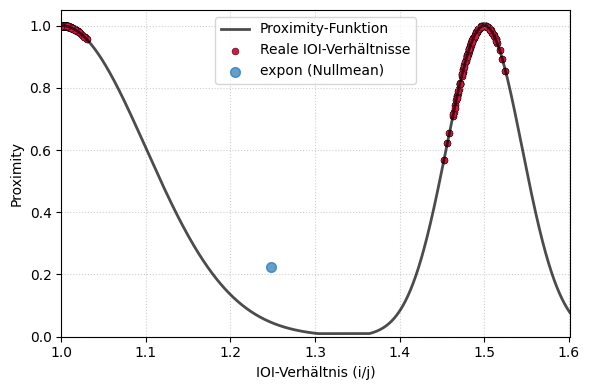

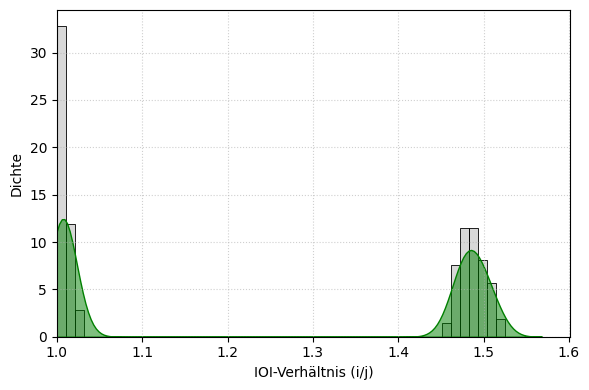

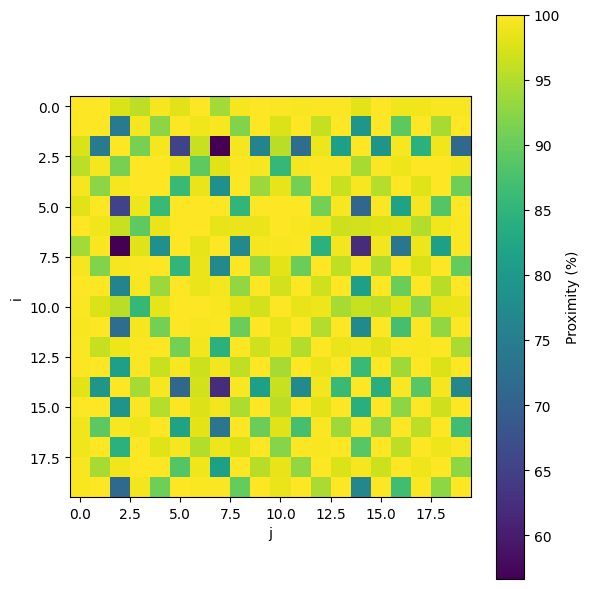

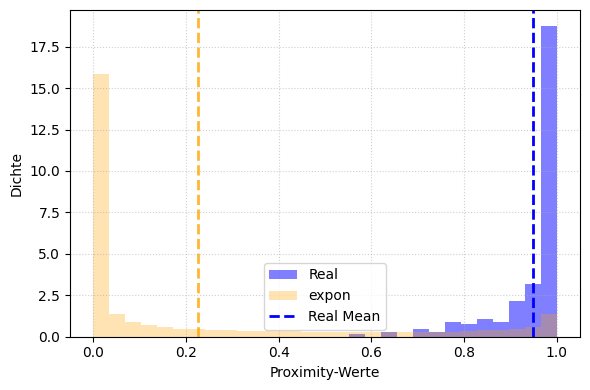

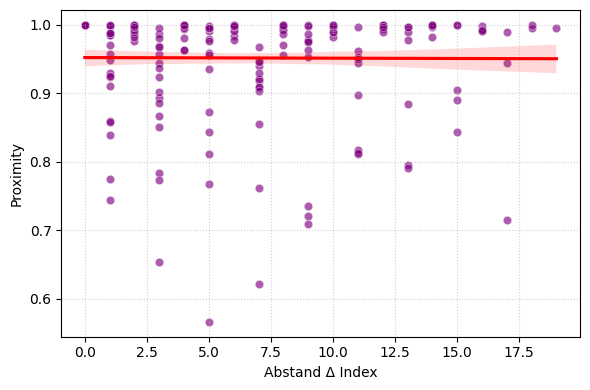

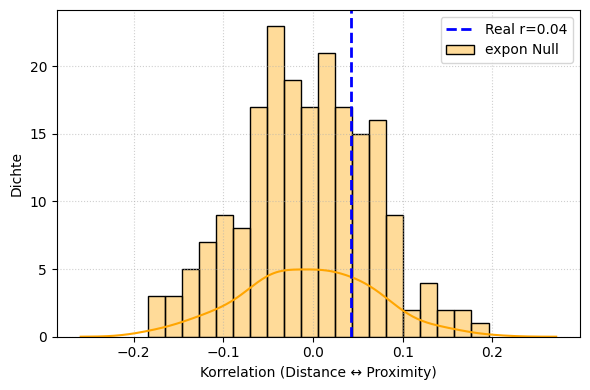

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from proximitylib.proximity import (
    build_pairwise_proximity_df,
    proximity_max_freq_gaussian_table,
    param_sets,
    analyze_single_sequence
)

# ===============================================================
#  Vorbereitung: IOIs laden & Grunddaten vorbereiten
# ===============================================================

def prepare_sequence_data(file_path, param_choice=3, num_sequences=200, seed=42, models=("expon", "uniform")):
    df = pd.read_csv(file_path)
    iois = df["IOI"].dropna().values
    params = param_sets[param_choice]

    df_pairs, ratios, prox_mat = build_pairwise_proximity_df(iois, params)
    results = analyze_single_sequence(iois, params, num_sequences=num_sequences, plot=False, seed=seed, models=models)
    return iois, df_pairs, results, params

# ===============================================================
#  Einzelplots
# ===============================================================

def plot_proximity_function(df_pairs, results, params, figsize=(6,4)):
    """
    Zeigt Proximity-Funktion + reale IOI-Ratios (rot) + Nullmodellmittelwerte (orange).
    """
    x_min = max(1.0, df_pairs["ratio"].min()*0.95)
    x_max = df_pairs["ratio"].max()*1.05
    x_range = np.linspace(x_min, x_max, 2000)
    y_curve, _ = proximity_max_freq_gaussian_table(x_range, **params)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(x_range, y_curve, color="black", lw=2, alpha=0.7, label="Proximity-Funktion")
    ax.scatter(df_pairs["ratio"], df_pairs["prox_value"], s=25, color="crimson",
               edgecolor="black", lw=0.3, label="Reale IOI-Verhältnisse")

    # Nullsequenzen-Mittelwerte als Punkte
    for model, vals in results["null_proximities"].items():
        mean_x = np.mean(df_pairs["ratio"])
        mean_y = np.mean(vals)
        ax.scatter(mean_x, mean_y, s=50, label=f"{model} (Nullmean)", alpha=0.7)

    ax.set_xlabel("IOI-Verhältnis (i/j)")
    ax.set_ylabel("Proximity")
    ax.legend()
    ax.grid(True, ls=":", alpha=0.6)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

def plot_ratio_distribution(df_pairs, figsize=(6,4)):
    x_min = max(1.0, df_pairs["ratio"].min()*0.95)
    x_max = df_pairs["ratio"].max()*1.05
    fig, ax = plt.subplots(figsize=figsize)
    sns.histplot(df_pairs["ratio"], bins=50, stat="density", color="gray", alpha=0.3, ax=ax)
    sns.kdeplot(df_pairs["ratio"], fill=True, color="green", alpha=0.5, bw_adjust=0.2, ax=ax)
    ax.set_xlabel("IOI-Verhältnis (i/j)")
    ax.set_ylabel("Dichte")
    ax.grid(True, ls=":", alpha=0.6)
    ax.set_xlim(x_min, x_max)
    plt.tight_layout()
    plt.show()

def plot_histogram_real_vs_null(results, figsize=(6,4)):
    colors = {"Real":"blue", "expon":"orange", "uniform":"gray"}
    fig, ax = plt.subplots(figsize=figsize)
    bins = np.linspace(0,1,30)

    # Real
    ax.hist(results["proximity_real"], bins=bins, density=True, color="blue", alpha=0.5, label="Real")

    # Nullmodelle
    for model, vals in results["null_proximities"].items():
        color = colors.get(model,"gray")
        ax.hist(vals, bins=bins, density=True, alpha=0.3, color=color, label=f"{model}")
        # Vertikale Linie für Mittelwert
        ax.axvline(np.mean(vals), color=color, linestyle="--", lw=2, alpha=0.8)

    ax.axvline(np.mean(results["proximity_real"]), color="blue", linestyle="--", lw=2, label="Real Mean")
    ax.set_xlabel("Proximity-Werte")
    ax.set_ylabel("Dichte")
    ax.grid(True, ls=":", alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_distance_proximity(df_pairs, figsize=(6,4)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(x=df_pairs["distance"], y=df_pairs["prox_value"], alpha=0.4, color="purple", ax=ax)
    sns.regplot(x=df_pairs["distance"], y=df_pairs["prox_value"], scatter=False, color="red", ax=ax)
    ax.set_xlabel("Abstand Δ Index")
    ax.set_ylabel("Proximity")
    ax.grid(True, ls=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_distance_proximity_corr(results, figsize=(6,4)):
    colors = {"expon":"orange", "uniform":"gray"}
    fig, ax = plt.subplots(figsize=figsize)
    for model, vals in results["distance_corr_nulls"].items():
        sns.histplot(vals, bins=20, color=colors.get(model,"gray"), alpha=0.4, label=f"{model} Null", ax=ax)
        sns.kdeplot(vals, color=colors.get(model,"gray"), ax=ax)
    ax.axvline(results["distance_corr_real"], color="blue", ls="--", lw=2, label=f"Real r={results['distance_corr_real']:.2f}")
    ax.set_xlabel("Korrelation (Distance ↔ Proximity)")
    ax.set_ylabel("Dichte")
    ax.grid(True, ls=":", alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ===============================================================
#  Anwendung
# ===============================================================

file_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-2-3_jitter-0010_10.csv"
iois, df_pairs, results, params = prepare_sequence_data(file_path, param_choice=3, models=("expon",))

plot_proximity_function(df_pairs, results, params)
plot_ratio_distribution(df_pairs)
plot_proximity_matrix(df_pairs, params)
plot_histogram_real_vs_null(results)
plot_distance_proximity(df_pairs)
plot_distance_proximity_corr(results)


Parameter-Set: {'sharpness_base': 10.0, 'sharpness_growth': 0.1, 'decay': 0, 'max_freq': 2, 'x_max': 4, 'weight_exponent': 0.0, 'freq_sharpness_exp': 1.0, 'output_max': 1, 'threshold': 0.01}


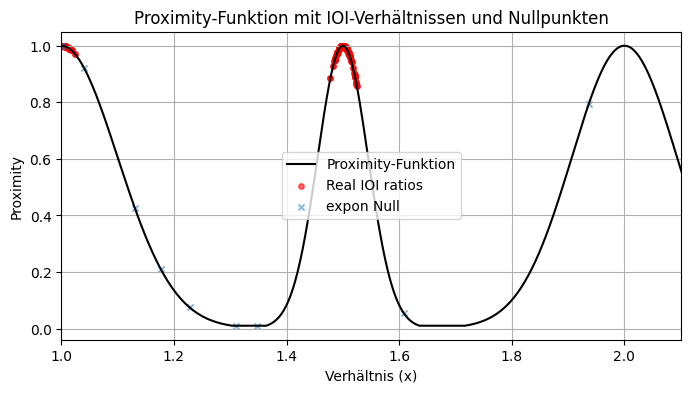

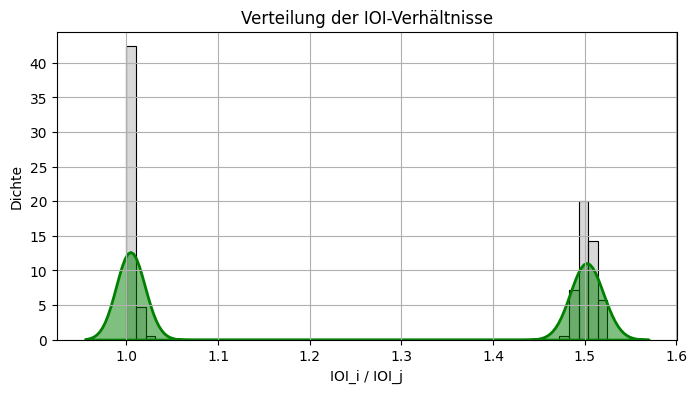

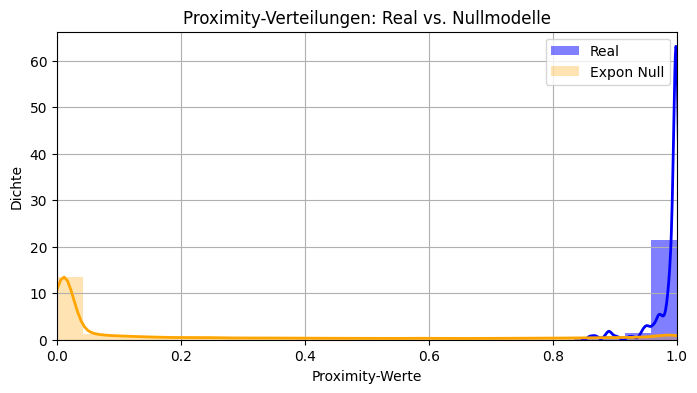

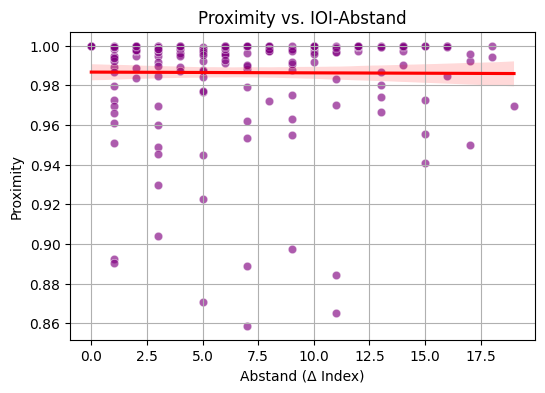

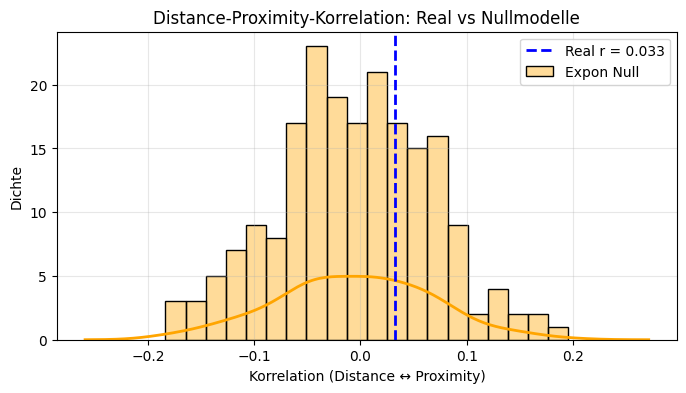


✅ Alle Teilplots erfolgreich erstellt.


In [69]:
"""
run_single_plots.py
Erzeugt einzelne Plots aus der Funktion new_plot_sequence_analysis().
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from proximitylib.proximity import proximity_max_freq_gaussian_table, build_pairwise_proximity_df, param_sets

def run_individual_plots(
    filename,
    base_dir,
    param_choice=1,
    null_models=("expon", "uniform"),
    num_sequences=200,
    seed=42,
    bins=25,
    top_k=5,
):
    # === Datei & Parameter laden ===
    path = Path(base_dir) / filename
    df = pd.read_csv(path)
    iois = df["IOI"].dropna().values
    params = param_sets[param_choice]
    print(f"Parameter-Set: {params}")

    # === Pairwise Proximity berechnen ===
    df_pairs, ratios, prox_max = prox.build_pairwise_proximity_df(iois, params)
    x_min = max(1.0, df_pairs["ratio"].min() * 0.95)
    x_max = df_pairs["ratio"].max() * 1.05
    x_range = np.linspace(1, x_max + 10, 5000)
    y_curve, _ = prox.proximity_max_freq_gaussian_table(x_range, **params)

    # === Nullmodell-Analyse ===
    results = analyze_single_sequence(
        iois,
        params=params,
        num_sequences=num_sequences,
        seed=seed,
        bins=bins,
        plot=False,
        models=null_models,
    )

    # ==========================================================
    # 1) Proximity-Funktion
    # ==========================================================
# ==========================================================
# 1) Proximity-Funktion + Nullpunkte
# ==========================================================
    plt.figure(figsize=(8, 4))
    plt.plot(x_range, y_curve, label="Proximity-Funktion", color="black")
    plt.scatter(df_pairs["ratio"], df_pairs["prox_value"], s=15, alpha=0.6, color="red", label="Real IOI ratios")

    # --- Nullpunkte einfügen ---
    num_null_points = 30  # <-- hier die Anzahl einstellen
    rng = np.random.default_rng(seed)
    null_sequences = {} 
    for model in null_models:
        # 1 Nullsequenz erzeugen
        sim_iois = None
        if model == "expon":
            sim_iois = rng.exponential(scale=np.median(iois), size=len(iois))
        elif model == "uniform":
            sim_iois = rng.uniform(np.min(iois), np.max(iois), size=len(iois))
        elif model == "empirical":
            sim_iois = rng.choice(iois, size=len(iois), replace=True)
        
        # Paare berechnen
        ratios_null = np.maximum(sim_iois[:, None], sim_iois[None, :]) / np.minimum(sim_iois[:, None], sim_iois[None, :])
        ratios_flat = ratios_null.flatten()
        prox_flat, _ = proximity_max_freq_gaussian_table(ratios_flat, **params)

        # Zufällige Indizes auswählen
        idx = rng.choice(len(ratios_flat), size=num_null_points, replace=False)
        plt.scatter(ratios_flat[idx], prox_flat[idx], s=20, alpha=0.5, label=f"{model} Null", marker="x")

    plt.xlabel("Verhältnis (x)")
    plt.ylabel("Proximity")
    plt.xlim(x_min, x_max + 0.5)
    plt.title("Proximity-Funktion mit IOI-Verhältnissen und Nullpunkten")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ==========================================================
    # 2) Verteilung der IOI-Verhältnisse
    # ==========================================================
    plt.figure(figsize=(8, 4))
    sns.histplot(df_pairs["ratio"], bins=50, stat="density", alpha=0.3, color="gray")
    sns.kdeplot(df_pairs["ratio"], fill=True, color="green", alpha=0.5, lw=2, bw_adjust=0.2)
    plt.xlabel("IOI_i / IOI_j")
    plt.ylabel("Dichte")
    plt.title("Verteilung der IOI-Verhältnisse")
    plt.grid(True)
    plt.show()

    # ==========================================================
    # 3) Histogramm: Real vs Nullmodelle
    # ==========================================================
    colors = {"Real": "blue", "expon": "orange", "uniform": "gray", "empirical": "green"}
    plt.figure(figsize=(8, 4))
    bin_edges = np.linspace(0, 1, bins)
    plt.hist(results["proximity_real"], bins=bin_edges, density=True, alpha=0.5, color="blue", label="Real")
    sns.kdeplot(results["proximity_real"], bw_adjust=0.4, color="blue", linewidth=2)
    for model, prox_vals in results["null_proximities"].items():
        color = colors.get(model, "black")
        plt.hist(prox_vals, bins=bin_edges, density=True, alpha=0.3, color=color, label=f"{model.capitalize()} Null")
        sns.kdeplot(prox_vals, bw_adjust=0.4, color=color, linewidth=2)
    plt.xlabel("Proximity-Werte")
    plt.xlim(0, 1)
    plt.ylabel("Dichte")
    plt.title("Proximity-Verteilungen: Real vs. Nullmodelle")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ==========================================================
    # 4) Scatterplot: Distance vs Proximity
    # ==========================================================
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df_pairs["distance"], y=df_pairs["prox_value"], alpha=0.4, color="purple")
    sns.regplot(x=df_pairs["distance"], y=df_pairs["prox_value"], scatter=False, color="red")
    plt.xlabel("Abstand (Δ Index)")
    plt.ylabel("Proximity")
    plt.title("Proximity vs. IOI-Abstand")
    plt.grid(True)
    plt.show()

    # ==========================================================
    # 5) Nullmodelle: Distance–Proximity-Korrelationen
    # ==========================================================
    plt.figure(figsize=(8, 4))
    colors_corr = {"expon": "orange", "uniform": "gray", "empirical": "green"}
    for model, corr_vals in results["distance_corr_nulls"].items():
        color = colors_corr.get(model, "black")
        sns.histplot(corr_vals, bins=20, color=color, alpha=0.4, label=f"{model.capitalize()} Null")
        sns.kdeplot(corr_vals, color=color, linewidth=2)
    plt.axvline(results["distance_corr_real"], color="blue", linestyle="--", linewidth=2,
                label=f"Real r = {results['distance_corr_real']:.3f}")
    plt.xlabel("Korrelation (Distance ↔ Proximity)")
    plt.ylabel("Dichte")
    plt.title("Distance-Proximity-Korrelation: Real vs Nullmodelle")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n✅ Alle Teilplots erfolgreich erstellt.")


# ==========================================================
# Beispiel-Aufruf
# ==========================================================
if __name__ == "__main__":
    base_dir = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.50/20beats/"
    filename = "heterochrony-2-3_jitter-0005_09.csv"
    run_individual_plots(filename, base_dir, param_choice=3, null_models=("expon",))


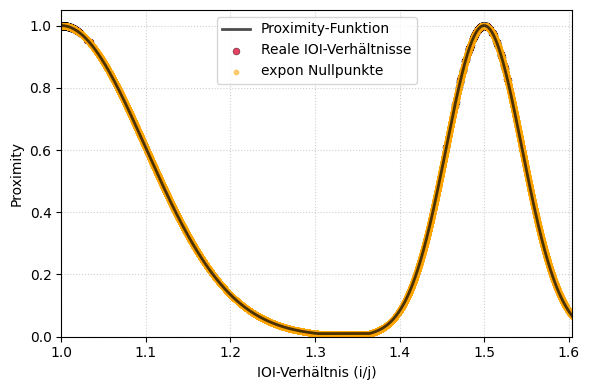

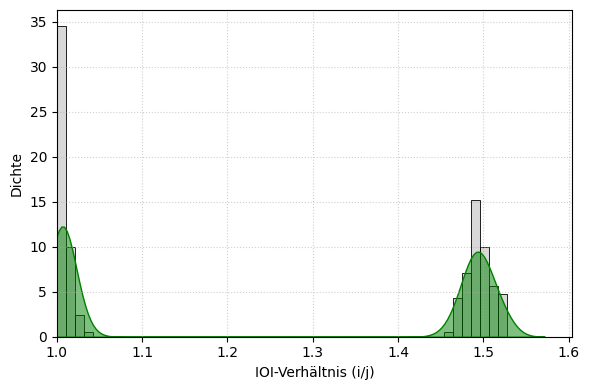

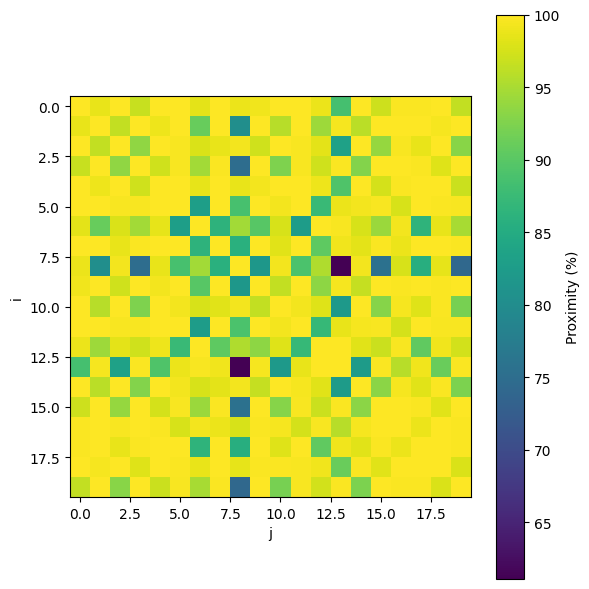

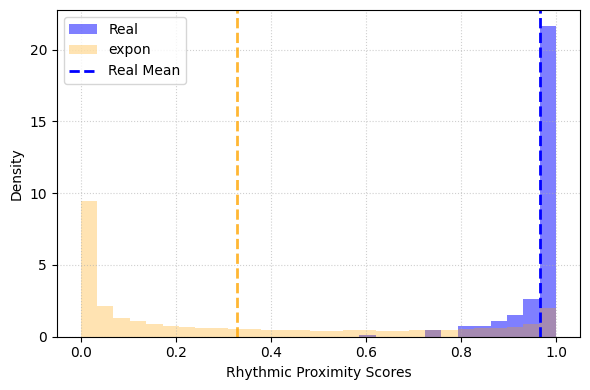

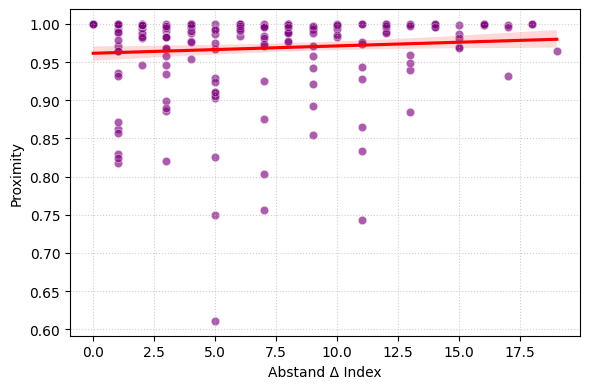

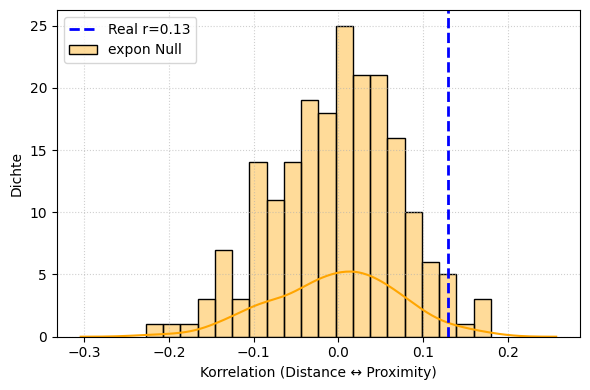

In [6]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate
import importlib

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))

import proximitylib.proximity as prox
importlib.reload(prox)

# ===============================================================
#  Vorbereitung: IOIs laden & Grunddaten vorbereiten
# ===============================================================

def prepare_sequence_data(file_path, param_choice=3, num_sequences=200, seed=42, models=("expon",)):
    df = pd.read_csv(file_path)
    iois = df["IOI"].dropna().values
    params = prox.param_sets[param_choice]

    df_pairs, ratios, prox_mat = prox.build_pairwise_proximity_df(iois, params)
    results = prox.analyze_single_sequence(
        iois, params, num_sequences=num_sequences, plot=False, seed=seed, models=models
    )
    return iois, df_pairs, results, params


# ===============================================================
#  Einzelplots
# ===============================================================

def plot_proximity_function(df_pairs, results, params, figsize=(6, 4)):
    """
    Zeigt Proximity-Funktion mit realen IOI-Ratios (rot)
    und Nullmodell-Punkten (orange) auf derselben Kurve.
    """
    # --- Bereich der Ratios ---
    x_min = max(1.0, df_pairs["ratio"].min() * 0.95)
    x_max = df_pairs["ratio"].max() * 1.05
    x_range = np.linspace(x_min, x_max, 2000)
    y_curve, _ = prox.proximity_max_freq_gaussian_table(x_range, **params)

    # --- Plot-Grundlage ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(x_range, y_curve, color="black", lw=2, alpha=0.7, label="Proximity-Funktion")

    # --- Reale Punkte ---
    ax.scatter(
        df_pairs["ratio"],
        df_pairs["prox_value"],
        s=25,
        color="crimson",
        edgecolor="black",
        lw=0.3,
        alpha=0.8,
        label="Reale IOI-Verhältnisse",
    )

    # --- Nullmodell-Punkte (liegen auf der Kurve) ---
    null_color = "orange"
    for model, null_vals in results["null_proximities"].items():
        # Wir nehmen gleichmäßig verteilte x-Werte (gleicher Bereich wie x_range)
        x_null = np.linspace(x_min, x_max, len(null_vals))
        y_null, _ = prox.proximity_max_freq_gaussian_table(x_null, **params)
        ax.scatter(x_null, y_null, s=10, color=null_color, alpha=0.5, label=f"{model} Nullpunkte")

    # --- Styling ---
    ax.set_xlabel("IOI-Verhältnis (i/j)")
    ax.set_ylabel("Proximity")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1.05)
    ax.grid(True, ls=":", alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_ratio_distribution(df_pairs, figsize=(6, 4)):
    x_min = max(1.0, df_pairs["ratio"].min() * 0.95)
    x_max = df_pairs["ratio"].max() * 1.05
    fig, ax = plt.subplots(figsize=figsize)
    sns.histplot(df_pairs["ratio"], bins=50, stat="density", color="gray", alpha=0.3, ax=ax)
    sns.kdeplot(df_pairs["ratio"], fill=True, color="green", alpha=0.5, bw_adjust=0.2, ax=ax)
    ax.set_xlabel("IOI-Verhältnis (i/j)")
    ax.set_ylabel("Dichte")
    ax.grid(True, ls=":", alpha=0.6)
    ax.set_xlim(x_min, x_max)
    plt.tight_layout()
    plt.show()


def plot_proximity_matrix(df_pairs, params, figsize=(6, 6)):
    pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot_vals, cmap="viridis", origin="upper")
    plt.colorbar(im, ax=ax, label="Proximity (%)")
    ax.set_xlabel("j")
    ax.set_ylabel("i")
    plt.tight_layout()
    plt.show()


def plot_histogram_real_vs_null(results, figsize=(6, 4)):
    colors = {"Real": "blue", "expon": "orange", "uniform": "gray"}
    fig, ax = plt.subplots(figsize=figsize)
    bins = np.linspace(0, 1, 30)

    # Real
    ax.hist(
        results["proximity_real"],
        bins=bins,
        density=True,
        color="blue",
        alpha=0.5,
        label="Real",
    )

    # Nullmodelle
    for model, vals in results["null_proximities"].items():
        color = colors.get(model, "gray")
        ax.hist(vals, bins=bins, density=True, alpha=0.3, color=color, label=f"{model}")
        # Vertikale Linie für Mittelwert
        ax.axvline(np.mean(vals), color=color, linestyle="--", lw=2, alpha=0.8)

    ax.axvline(
        np.mean(results["proximity_real"]),
        color="blue",
        linestyle="--",
        lw=2,
        label="Real Mean",
    )
    ax.set_xlabel("Rhythmic Proximity Scores")
    ax.set_ylabel("Density")
    ax.grid(True, ls=":", alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_distance_proximity(df_pairs, figsize=(6, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(x=df_pairs["distance"], y=df_pairs["prox_value"], alpha=0.4, color="purple", ax=ax)
    sns.regplot(x=df_pairs["distance"], y=df_pairs["prox_value"], scatter=False, color="red", ax=ax)
    ax.set_xlabel("Abstand Δ Index")
    ax.set_ylabel("Proximity")
    ax.grid(True, ls=":", alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_distance_proximity_corr(results, figsize=(6, 4)):
    colors = {"expon": "orange", "uniform": "gray"}
    fig, ax = plt.subplots(figsize=figsize)
    for model, vals in results["distance_corr_nulls"].items():
        sns.histplot(vals, bins=20, color=colors.get(model, "gray"), alpha=0.4, label=f"{model} Null", ax=ax)
        sns.kdeplot(vals, color=colors.get(model, "gray"), ax=ax)
    ax.axvline(results["distance_corr_real"], color="blue", ls="--", lw=2, label=f"Real r={results['distance_corr_real']:.2f}")
    ax.set_xlabel("Korrelation (Distance ↔ Proximity)")
    ax.set_ylabel("Dichte")
    ax.grid(True, ls=":", alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()


# ===============================================================
#  Anwendung
# ===============================================================

file_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.60/20beats/heterochrony-2-3_jitter-0010_10.csv"
iois, df_pairs, results, params = prepare_sequence_data(file_path, param_choice=3, models=("expon",))

plot_proximity_function(df_pairs, results, params)
plot_ratio_distribution(df_pairs)
plot_proximity_matrix(df_pairs, params)
plot_histogram_real_vs_null(results)
plot_distance_proximity(df_pairs)
plot_distance_proximity_corr(results)


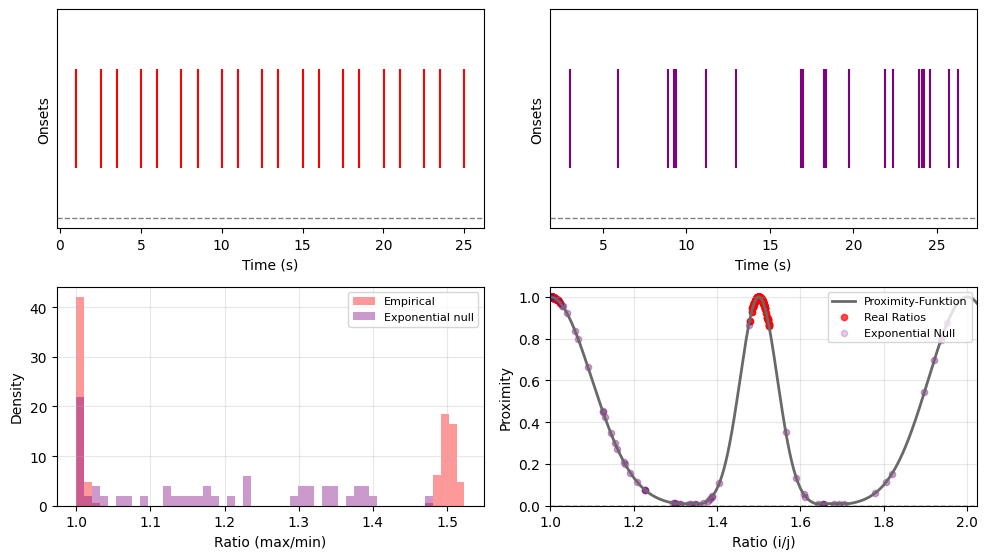

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from proximitylib.proximity import (
    build_pairwise_proximity_df,
    proximity_max_freq_gaussian_table,
    param_sets
)

def plot_sequence_panel_with_expon_onsets(file_path, param_choice=3, seed=42):
    """
    Zeigt für eine einzelne CSV-Sequenz:
    1) Onsets der echten Sequenz (rot)
    2) Onsets einer Nullsequenz (lila)
    3) Ratio-Histogramm (empirisch vs. exponentielle Null)
    4) Proximity-Funktion mit allen Nullpunkten und echten Punkten
    """
    rng = np.random.default_rng(seed)
    df = pd.read_csv(file_path)
    iois = df["IOI"].dropna().values
    onsets_real = np.cumsum(iois)
    params = param_sets[param_choice]

    # --- Erzeuge eine Nullsequenz ---
    iois_null = rng.exponential(scale=np.mean(iois), size=len(iois))
    onsets_null = np.cumsum(iois_null)

    # --- Ratios und Proximity für reale Sequenz ---
    df_pairs, ratios, _ = build_pairwise_proximity_df(iois, params)
    x_min = 1
    x_max = np.percentile(df_pairs["ratio"], 99)
    x_range = np.linspace(x_min, x_max + 1, 2000)
    y_curve, _ = proximity_max_freq_gaussian_table(x_range, **params)

    # --- Exponentielles Nullmodell ---
    ratios_exp = np.maximum(iois_null[:, None], iois_null[None, :]) / np.minimum(iois_null[:, None], iois_null[None, :])
    ratios_exp_flat = ratios_exp.flatten()
    prox_exp_flat, _ = proximity_max_freq_gaussian_table(ratios_exp_flat, **params)

    # --- Plot ---
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs = axs.flatten()
    #fig.suptitle(f"Sequence Analysis: {Path(file_path).stem}", fontsize=14, weight='bold')

    # 1) Echte Onsets (rot)
    axs[0].eventplot(onsets_real, color='red')
    axs[0].set_xlabel("Time (s)")
    axs[0].set_ylabel("Onsets")
    axs[0].set_yticks([])
    axs[0].axhline(0, color='gray', lw=1, linestyle='--')
    #axs[0].set_title("Real Sequence")
    axs[0].grid(False)

    # 2) Nullsequenz Onsets (lila)
    axs[1].eventplot(onsets_null, color='purple')
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Onsets")
    axs[1].set_yticks([])
    axs[1].axhline(0, color='gray', lw=1, linestyle='--')
    #axs[1].set_title("Exponential Null Sequence")
    axs[1].grid(False)

    # 3) Ratio-Histogramm
    bins_lin = np.linspace(x_min, x_max, 50)
    r_real_flat = (np.maximum(iois[:, None], iois[None, :]) / np.minimum(iois[:, None], iois[None, :])).flatten()
    axs[2].hist(r_real_flat, bins=bins_lin, density=True, alpha=0.4, color='red', label='Empirical')
    axs[2].hist(ratios_exp_flat, bins=bins_lin, density=True, alpha=0.4, color='purple', label='Exponential null')
    axs[2].set_xlabel("Ratio (max/min)")
    axs[2].set_ylabel("Density")
    axs[2].grid(alpha=0.3)
    axs[2].legend(fontsize=8)
    #axs[2].set_title("Empirical vs. Exponential Null Ratios")

    # 4) Proximity-Funktion mit allen Nullpunkten
    axs[3].plot(x_range, y_curve, color='dimgray', lw=2, label="Proximity-Funktion")
    axs[3].scatter(r_real_flat, proximity_max_freq_gaussian_table(r_real_flat, **params)[0], 
                   s=20, color='red', alpha=0.7, label="Real Ratios")
    axs[3].scatter(ratios_exp_flat, prox_exp_flat, s=20, color='purple', alpha=0.2, label="Exponential Null")
    axs[3].axhline(0, color='black', lw=1, linestyle='--')
    axs[3].set_xlabel("Ratio (i/j)")
    axs[3].set_ylabel("Proximity")
    axs[3].set_xlim(x_min, x_max + 0.5)
    axs[3].set_ylim(0, 1.05)
    axs[3].grid(alpha=0.3)
    axs[3].legend(fontsize=8, loc='upper right')
    #axs[3].set_title("Proximity Function with Real and Null Ratios")

    # Leere Subplots
    for ax in axs[4:]:
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# === Beispielaufruf ===
file_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-2-3_jitter-0005_09.csv"
plot_sequence_panel_with_expon_onsets(file_path, param_choice=3)


In [10]:
# Tabellen der Ergebnisse für verschiedene Datensätze erstellen

import sys
from pathlib import Path

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))  # geht eine Ebene hoch

import importlib
import proximitylib.proximity as prox
from tabulate import tabulate
importlib.reload(prox)

def plot_sequence_panel_with_expon_onsets(file_path, param_choice=3, seed=42):
    """
    Zeigt für eine einzelne CSV-Sequenz:
    1) Onsets der echten Sequenz (blau)
    2) Onsets einer Nullsequenz (orange)
    3) Ratio-Histogramm (empirisch vs. exponentielle Null)
    4) Proximity-Funktion mit allen Nullpunkten und echten Punkten
    """
    rng = np.random.default_rng(seed)
    df = pd.read_csv(file_path)
    iois = df["IOI"].dropna().values
    onsets_real = np.cumsum(iois)
    params = param_sets[param_choice]

    # --- Erzeuge eine Nullsequenz ---
    iois_null = rng.exponential(scale=np.mean(iois), size=len(iois))
    onsets_null = np.cumsum(iois_null)

    # --- Ratios und Proximity für reale Sequenz ---
    df_pairs, ratios, _ = build_pairwise_proximity_df(iois, params)
    x_min = 1
    x_max = np.percentile(df_pairs["ratio"], 99)
    x_range = np.linspace(x_min, x_max + 1, 2000)
    y_curve, _ = proximity_max_freq_gaussian_table(x_range, **params)

    # --- Exponentielles Nullmodell ---
    ratios_exp_matrix = np.maximum(iois_null[:, None], iois_null[None, :]) / np.minimum(iois_null[:, None, :])
    ratios_exp_flat = ratios_exp_matrix[np.triu_indices_from(ratios_exp_matrix, k=1)]

    ratios_exp_flat = ratios_exp.flatten()
    prox_exp_flat, _ = proximity_max_freq_gaussian_table(ratios_exp_flat, **params)

    # --- Plot ---
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs = axs.flatten()

    # 1) Echte Onsets (blau)
    axs[0].eventplot(onsets_real, color='blue', lineoffsets=0, linelengths=1)
    axs[0].axhline(0, color='black', lw=1)  # Mittellinie
    axs[0].set_xlabel("Time (s)")
    axs[0].set_ylabel("Onsets")
    axs[0].set_yticks([])
    axs[0].grid(False)
    axs[0].set_title("Real Sequence Onsets (blue)")

    # 2) Nullsequenz Onsets (orange)
    axs[1].eventplot(onsets_null, color='orange', lineoffsets=0, linelengths=1)
    axs[1].axhline(0, color='black', lw=1)  # Mittellinie
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Onsets")
    axs[1].set_yticks([])
    axs[1].grid(False)
    axs[1].set_title("Example of a Null Sequence (orange)")

    # 3) Ratio-Histogramm
    bins_lin = np.linspace(x_min, x_max, 50)
    ratios_matrix = np.maximum(iois[:, None], iois[None, :]) / np.minimum(iois[:, None, :])
    ratios_real = ratios_matrix[np.triu_indices_from(ratios_matrix, k=1)]
    axs[2].hist(ratios_real, bins=bins_lin, density=True, alpha=0.7, color='blue', label='Real')
    axs[2].hist(ratios_exp_flat, bins=bins_lin, density=True, alpha=0.5, color='orange', label='Null')
    axs[2].set_xlabel("IOI-Ratios")
    axs[2].set_ylabel("Density")
    axs[2].grid(alpha=0.3)
    axs[2].legend(fontsize=8)

    # 4) Proximity-Funktion mit allen Nullpunkten
    axs[3].plot(x_range, y_curve, color='grey', lw=2, label="Proximity function")
    axs[3].scatter(ratios_real, proximity_max_freq_gaussian_table(ratios_real, **params)[0], 
                   s=20, color='blue', alpha=0.7, label="Real Ratios")
    axs[3].scatter(ratios_exp_flat, prox_exp_flat, s=20, color='orange', alpha=0.7, label="Null Ratios")
    axs[3].axhline(0, color='black', lw=1, linestyle='--')
    axs[3].set_xlabel("IOI-Ratios")
    axs[3].set_ylabel("Rhythmic Proximity")
    axs[3].set_xlim(x_min, x_max + 0.5)
    axs[3].set_ylim(0, 1.05)
    axs[3].grid(alpha=0.3)
    axs[3].legend(fontsize=8, loc='upper right')



    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.subplots_adjust(hspace=0.4)
    plt.show()


# === Beispielaufruf ===
file_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-2-3_jitter-0005_09.csv"
plot_sequence_panel_with_expon_onsets(file_path, param_choice=3, seed=45)


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [3]:
# Tabellen der Ergebnisse für verschiedene Datensätze erstellen

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate
import importlib

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))

import proximitylib.proximity as prox
importlib.reload(prox)

def plot_sequence_panel_with_expon_onsets(file_path, param_choice=3, seed=42):
    """
    Zeigt für eine einzelne CSV-Sequenz:
    1) Onsets der echten Sequenz (blau)
    2) Onsets einer Nullsequenz (orange)
    3) Ratio-Histogramm (empirisch vs. exponentielle Null)
    4) Proximity-Funktion mit allen Nullpunkten und echten Punkten
    """
    rng = np.random.default_rng(seed)
    df = pd.read_csv(file_path)
    iois = df["IOI"].dropna().values
    onsets_real = np.cumsum(iois)
    params = param_sets[param_choice]

    # --- Erzeuge eine Nullsequenz ---
    iois_null = rng.exponential(scale=np.mean(iois), size=len(iois))
    onsets_null = np.cumsum(iois_null)

    # --- Ratios und Proximity für reale Sequenz ---
    df_pairs, ratios, _ = prox.build_pairwise_proximity_df(iois, params)
    x_min = 1
    x_max = np.percentile(df_pairs["ratio"], 99)
    x_range = np.linspace(x_min, x_max + 1, 2000)
    y_curve, _ = prox.proximity_max_freq_gaussian_table(x_range, **params)

    # --- Exponentielles Nullmodell ---
    ratios_exp_matrix = np.maximum(iois_null[:, None], iois_null[None, :]) / np.minimum(iois_null[:, None], iois_null[None, :])
    ratios_exp_flat = ratios_exp_matrix[np.triu_indices_from(ratios_exp_matrix, k=1)]
    prox_exp_flat, _ = prox.proximity_max_freq_gaussian_table(ratios_exp_flat, **params)

    # --- Plot ---
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs = axs.flatten()

    # 1) Echte Onsets (blau)
    axs[0].eventplot(onsets_real, color='blue', lineoffsets=0, linelengths=1)
    axs[0].axhline(0, color='black', lw=1)
    axs[0].set_xlabel("Time (s)")
    axs[0].set_ylabel("Onsets")
    axs[0].set_yticks([])
    axs[0].grid(False)
    axs[0].set_title("Real Sequence Onsets (blue)")

    # 2) Nullsequenz Onsets (orange)
    axs[1].eventplot(onsets_null, color='orange', lineoffsets=0, linelengths=1)
    axs[1].axhline(0, color='black', lw=1)
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Onsets")
    axs[1].set_yticks([])
    axs[1].grid(False)
    axs[1].set_title("Example of a Null Sequence (orange)")

    # 3) Ratio-Histogramm
    bins_lin = np.linspace(x_min, x_max, 50)
    ratios_matrix = np.maximum(iois[:, None], iois[None, :]) / np.minimum(iois[:, None], iois[None, :])
    ratios_real = ratios_matrix[np.triu_indices_from(ratios_matrix, k=1)]
    axs[2].hist(ratios_real, bins=bins_lin, density=True, alpha=0.7, color='blue', label='Real')
    axs[2].hist(ratios_exp_flat, bins=bins_lin, density=True, alpha=0.5, color='orange', label='Null')
    axs[2].set_xlabel("IOI-Ratios")
    axs[2].set_ylabel("Density")
    axs[2].grid(alpha=0.3)
    axs[2].legend(fontsize=8)

    # 4) Proximity-Funktion
    axs[3].plot(x_range, y_curve, color='grey', lw=2, label="Proximity function")
    axs[3].scatter(ratios_real, prox.proximity_max_freq_gaussian_table(ratios_real, **params)[0], 
                   s=20, color='blue', alpha=0.7, label="Real Ratios")
    axs[3].scatter(ratios_exp_flat, prox_exp_flat, s=20, color='orange', alpha=0.7, label="Null Ratios")
    axs[3].axhline(0, color='black', lw=1, linestyle='--')
    axs[3].set_xlabel("IOI-Ratios")
    axs[3].set_ylabel("Rhythmic Proximity")
    axs[3].set_xlim(x_min, x_max + 0.5)
    axs[3].set_ylim(0, 1.05)
    axs[3].grid(alpha=0.3)
    axs[3].legend(fontsize=8, loc='upper right')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.subplots_adjust(hspace=0.4)
    plt.show()


# === Beispielaufruf ===
file_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-2-3_jitter-0010_09.csv"
plot_sequence_panel_with_expon_onsets(file_path, param_choice=3, seed=45)


NameError: name 'param_sets' is not defined